# Análise de Dados — Carcinoma Basocelular
## PIBIC / LMECC

Estudo retrospectivo de biópsias de carcinoma basocelular (CBC). Este notebook
realiza o tratamento e a limpeza dos dados, a representação descritiva dos
pacientes e os testes de associação entre variáveis clínicas, histopatológicas
e ocupacionais.

**Unidade de análise:**
- *Nível paciente* (deduplicado pelo Código da Amostra): perfil demográfico —
  idade, sexo, profissão — e a comparação de idade entre sexos.
- *Nível lesão* (todas as biópsias): tabelas cruzadas histopatológicas.

**Conjunto de análises:**

1. Descritiva do perfil dos pacientes (idade, sexo, profissão, etnia, estado civil).
2. Comparação da idade entre homens e mulheres.
3. Margens comprometidas × Reincidência.
4. Bloco A — Estado civil (com/sem companheiro) × profundidade, tamanho, ulceração
   e margens, estratificado por sexo.
5. Bloco B — Faixa etária (≤ 40 vs > 40 anos) × marcadores de agressividade.
6. Bloco C — Exposição solar ocupacional × marcadores de agressividade.
7. Bloco D — Região anatômica (face detalhada) × variáveis clínicas e patológicas.
8. Bloco E — Subtipo do tumor (3 categorias clínicas) × variáveis clínicas e patológicas.

**Padrão estatístico:** qui-quadrado de Pearson para variáveis categóricas
(exato de Fisher quando 2×2 com frequência esperada inferior a 5);
Mann-Whitney para variáveis contínuas em dois grupos e Kruskal-Wallis em três
ou mais; teste de normalidade (Shapiro-Wilk) precedendo a comparação de idade
entre sexos. Significância α = 0,05. Tamanho de efeito reportado conforme o
teste utilizado (V de Cramer, r rank-biserial, d de Cohen, η²).


## 1. Configuração do ambiente

In [1]:
import os, re, unicodedata, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "font.size": 11})

ARQUIVO = "Dados_PIBIC_LMECC_Completo(Banco de Dados) (1).csv"
FIG_DIR = "figuras"
os.makedirs(FIG_DIR, exist_ok=True)

# acumulador de resultados (tabela-mestre)
RESULTADOS = []

def salvar_fig(nome):
    plt.savefig(os.path.join(FIG_DIR, nome))
    print(f"[figura] {nome}")
print("Ambiente pronto.")

Ambiente pronto.


## 2. Carga dos dados

In [2]:
brutos = pd.read_csv(ARQUIVO, sep=None, engine="python", encoding="utf-8-sig")
print(f"Dimensões: {brutos.shape[0]} linhas × {brutos.shape[1]} colunas")
print("\nColunas:")
for c in brutos.columns: print(f"  - {c}")
brutos.head(3)

Dimensões: 419 linhas × 20 colunas

Colunas:
  - Código da Amostra
  - Data do diagnóstico
  - Tipo de Material Analisado
  - Idade ao diagnóstico
  - Sexo
  - Etnia
  - Estado Civil
  - Profissão
  - Subtipo do Tumor
  - Região Anatômica da Lesão
  - Tamanho da Lesão (cm)
  - Presença de Ulceração
  - infiltração
  - Estado de Comprometimento das Margens (Lateral)
  - Estado de Comprometimento das Margens (Profunda)
  - Reincidência?
  - Quantas reincidências?
  - Invasão Linfovascular?
  - Invasão Perineural?
  - Tratamento


,Código da Amostra,Data do diagnóstico,Tipo de Material Analisado,Idade ao diagnóstico,Sexo,Etnia,Estado Civil,Profissão,Subtipo do Tumor,Região Anatômica da Lesão,Tamanho da Lesão (cm),Presença de Ulceração,infiltração,Estado de Comprometimento das Margens (Lateral),Estado de Comprometimento das Margens (Profunda),Reincidência?,Quantas reincidências?,Invasão Linfovascular?,Invasão Perineural?,Tratamento
0,77043,2022,Biópsia,70,Masculino,Branca,Divorciado(a),advogado,basoescamoso,dorso,1,Não,derme reticular,livres,livres,Não,NaN,Não,Não,NaN
1,71171,2021,Biópsia,78,Masculino,Negra,Casado(a),trabalhador agrícola,misto (solido e basoescamoso),face (nariz),"2,3",Sim,derme reticular média,livres,livres,Não,NaN,Não,Não,NaN
2,55704,2020,Biópsia,81,Feminino,Branca,Casado(a),aposentada,misto (superficial e esclerodermiforme),face (frontal),"1,6",Não,NaN,livres,livres,NaN,NaN,NaN,Não,NaN


## 3. Tratamento e limpeza dos dados

A base apresenta inconsistências típicas de digitação manual. Os tratamentos
aplicados estão resumidos abaixo:

| Coluna | Problema | Tratamento |
|---|---|---|
| Idade ao diagnóstico | textos não numéricos | conversão para numérico, inválidos → ausente |
| Etnia | maiúsculas inconsistentes | padronização |
| Estado Civil | valor `Branca` infiltrado | remoção do valor incorreto |
| Profissão | acentos, plurais, gênero | normalização |
| Subtipo do Tumor | 58 variações de `misto (...)` | normalização e classificação em grupos clínicos |
| Infiltração (grau) | 32 variações textuais | escala ordinal de profundidade |
| Ulceração | `Não informado` | mantém Sim/Não; demais → ausente |
| Margens (Lateral e Profunda) | texto livre (`comprometidas (1)`, espaços) | normalização e flag combinada |
| Reincidência | `Talvez`, ausentes | mantém Sim/Não; demais → ausente |
| Invasão Linfovascular | apenas `Não` e ausentes | mantida (sem casos positivos) |
| Tamanho da Lesão | vírgula decimal e ruído numérico | conversão para numérico, arredondamento |
| Tipo de Material / Tratamento | colunas constantes ou vazias | descartadas |


In [3]:
def sem_acento(s):
    if pd.isna(s): return s
    s = unicodedata.normalize("NFKD", str(s))
    return "".join(c for c in s if not unicodedata.combining(c))

def norm(s):
    if pd.isna(s): return np.nan
    s = sem_acento(str(s)).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s if s else np.nan

df = brutos.rename(columns={
    "Código da Amostra": "codigo",
    "Data do diagnóstico": "data_dx",
    "Idade ao diagnóstico": "idade",
    "Sexo": "sexo",
    "Etnia": "etnia",
    "Estado Civil": "estado_civil",
    "Profissão": "profissao",
    "Subtipo do Tumor": "subtipo_raw",
    "Região Anatômica da Lesão": "regiao_raw",
    "Tamanho da Lesão (cm)": "tamanho_cm",
    "Presença de Ulceração": "ulceracao",
    "infiltração": "infiltracao_raw",
    "Estado de Comprometimento das Margens (Lateral)": "margem_lat_raw",
    "Estado de Comprometimento das Margens (Profunda)": "margem_prof_raw",
    "Reincidência?": "reincidencia",
    "Quantas reincidências?": "qtd_reincidencias",
    "Invasão Linfovascular?": "inv_linfovascular",
    "Invasão Perineural?": "inv_perineural",
}).drop(columns=["Tipo de Material Analisado", "Tratamento"], errors="ignore")

# numérico: idade
df["idade"] = pd.to_numeric(df["idade"], errors="coerce")

# numérico: tamanho da lesão (CSV usa vírgula decimal)
df["tamanho_cm"] = (df["tamanho_cm"].astype(str)
                                    .str.replace(",", ".", regex=False)
                                    .replace({"nan": np.nan}))
df["tamanho_cm"] = pd.to_numeric(df["tamanho_cm"], errors="coerce").round(2)

# categorias simples
df["sexo"]  = df["sexo"].astype(str).str.strip().str.title().replace({"Nan": np.nan})
df["etnia"] = df["etnia"].astype(str).str.strip().str.title().replace({"Nan": np.nan})
df["estado_civil"] = df["estado_civil"].where(df["estado_civil"] != "Branca")

df["ulceracao"]         = df["ulceracao"].apply(norm).map({"sim":"Sim","nao":"Não"})
df["reincidencia"]      = df["reincidencia"].apply(norm).map({"sim":"Sim","nao":"Não"})
df["inv_perineural"]    = df["inv_perineural"].apply(norm).map({"sim":"Sim","nao":"Não"})
df["inv_linfovascular"] = df["inv_linfovascular"].apply(norm).map({"sim":"Sim","nao":"Não"})

print("Variáveis simples normalizadas. n =", len(df))

Variáveis simples normalizadas. n = 419


### 3.1. Margens — normalização e flag combinada
Texto livre como `comprometidas (1)` ou `comprometida ` é normalizado para
*livre* ou *comprometida*. A flag combinada `margem_comprometida` registra
*Comprometida* quando há comprometimento em margem lateral ou profunda.

In [4]:
def normaliza_margem(s):
    s = norm(s)
    if pd.isna(s): return np.nan
    if "comprometid" in s: return "Comprometida"
    if "livre" in s: return "Livre"
    return np.nan

df["margem_lateral"]  = df["margem_lat_raw"].apply(normaliza_margem)
df["margem_profunda"] = df["margem_prof_raw"].apply(normaliza_margem)

def combina_margem(row):
    vals = [row["margem_lateral"], row["margem_profunda"]]
    if "Comprometida" in vals: return "Comprometida"
    if "Livre" in vals: return "Livre"
    return np.nan
df["margem_comprometida"] = df.apply(combina_margem, axis=1)

print(df["margem_comprometida"].value_counts(dropna=False))

margem_comprometida
Livre           363
Comprometida     53
NaN               3
Name: count, dtype: int64


### 3.2. Grau de infiltração — escala ordinal

As 32 descrições textuais foram colapsadas em quatro níveis de profundidade
crescente:

1. **Derme** (superficial/média)
2. **Derme reticular** (inclui derme profunda)
3. **Hipoderme / tecido subcutâneo**
4. **Estruturas profundas** (músculo, cartilagem, globo ocular, tecidos periorbitários)

In [5]:
ORDEM_GRAU = ["1. Derme", "2. Derme reticular",
              "3. Hipoderme/subcutâneo", "4. Estruturas profundas"]

def classifica_grau(s):
    s = norm(s)
    if pd.isna(s) or "nao informado" in s: return np.nan
    if any(k in s for k in ["globo ocular","muscul","musc","cartilagem","periorbit","estriad"]):
        return "4. Estruturas profundas"
    if any(k in s for k in ["hipoderme","subcut","adiposo","celular subc"]):
        return "3. Hipoderme/subcutâneo"
    if "reticular" in s or "derme profunda" in s: return "2. Derme reticular"
    if "derme" in s: return "1. Derme"
    return np.nan

df["grau_infiltracao"] = pd.Categorical(df["infiltracao_raw"].apply(classifica_grau),
                                        categories=ORDEM_GRAU, ordered=True)
print(df["grau_infiltracao"].value_counts(dropna=False).sort_index())

grau_infiltracao
1. Derme                    54
2. Derme reticular         261
3. Hipoderme/subcutâneo     60
4. Estruturas profundas     14
NaN                         30
Name: count, dtype: int64

### 3.3. Subtipo do tumor — classificação em três grupos clínicos

Aplica-se a classificação clínica padrão de CBC (WHO / NCCN) baseada no
risco de comportamento agressivo:

| Grupo | Componentes histológicos |
|---|---|
| **Baixo risco** (indolente) | nodular, sólido, superficial, adenoide, pigmentado, queratótico |
| **Alto risco** (agressivo) | esclerodermiforme, infiltrativo, micronodular, basoescamoso, metatípico |
| **Misto** | combinação de componentes dos dois grupos acima |

Uma lesão classifica-se em *Misto* quando apresenta simultaneamente componentes
indolentes e agressivos.

In [6]:
BAIXO_RISCO = ["nodular","solido","superficial","adenoide","pigmentado","queratotico","ceratotico"]
ALTO_RISCO  = ["esclerodermiforme","infiltrativo","micronodular","basoescamoso","metatipico","metatpico"]

def limpa_subtipo(s):
    s = norm(s)
    if pd.isna(s): return np.nan
    s = (s.replace("eesclerodermiforme", "e esclerodermiforme")
          .replace("nodular a basoescamoso", "nodular e basoescamoso"))
    return re.sub(r"\s+", " ", s).strip()

df["subtipo"] = df["subtipo_raw"].apply(limpa_subtipo)

def classifica_subtipo(s):
    if pd.isna(s): return np.nan
    tem_baixo = any(k in s for k in BAIXO_RISCO)
    tem_alto  = any(k in s for k in ALTO_RISCO)
    if tem_baixo and tem_alto: return "Misto"
    if tem_alto:               return "Alto risco"
    if tem_baixo:              return "Baixo risco"
    return np.nan

ORDEM_SUB = ["Baixo risco","Misto","Alto risco"]
df["subtipo_3cat"] = pd.Categorical(df["subtipo"].apply(classifica_subtipo),
                                    categories=ORDEM_SUB, ordered=True)

# composição (puro/misto) - mantida da rodada 1 para a flag puro/misto
tem_misto_palavra = df["subtipo"].fillna("").str.contains("misto")
componentes_total = sum(df["subtipo"].fillna("").str.contains(p).astype(int)
                        for p in BAIXO_RISCO + ALTO_RISCO)
df["composicao"] = np.where(tem_misto_palavra | (componentes_total >= 2), "Misto", "Puro")
df["composicao"] = df["composicao"].astype(object)
df.loc[df["subtipo"].isna(), "composicao"] = np.nan

print("Subtipo (3 categorias):")
print(df["subtipo_3cat"].value_counts(dropna=False))
print("\nComposição (puro/misto):")
print(df["composicao"].value_counts(dropna=False))

Subtipo (3 categorias):
subtipo_3cat
Misto          272
Alto risco     147
Baixo risco      0
Name: count, dtype: int64

Composição (puro/misto):
composicao
Misto    290
Puro     129
Name: count, dtype: int64


### 3.4. Profissão e exposição solar ocupacional

A profissão é normalizada (acento, plural, gênero) e mapeada a duas categorias
de exposição solar ocupacional. Aposentado(a), autônomo(a), desempregado e
"não informado" são excluídos dessa variável binária por indeterminação.

In [7]:
df["profissao"] = df["profissao"].apply(norm).replace({"nao informado": np.nan,
                                                       "aposentada": "aposentado"})

COM_SOL = ["trabalhador agricola","lavrador","salineiro","pescador",
           "carpinteiro","marceneiro","eletricista","soldador","pintor",
           "trabalhador de obras","trabalhador de concreto armado",
           "trabalhador bracal","operador de maquinas","mecanico",
           "motorista","vigilante"]
SEM_SOL = ["do lar","comerciante","atendente","cozinheira","domestica",
           "domestica/copeira","vendedor","cabeleireira","lavadeira","asg",
           "seguranca","gerente de empresa",
           "professor","professora","medico","enfermeira",
           "auxiliar de enfermagem","tec enfermagem","policial",
           "funcionaria publica","funcionario publico","advogado"]

mapa_exp = {**{p:"Com exposição" for p in COM_SOL},
            **{p:"Sem exposição" for p in SEM_SOL}}
df["exposicao_solar"] = df["profissao"].map(mapa_exp)
print(df["exposicao_solar"].value_counts(dropna=False))

exposicao_solar
Com exposição    228
NaN               97
Sem exposição     94
Name: count, dtype: int64


### 3.5. Estado civil — agrupamento binário
Casado(a) e União estável → *Com companheiro(a)*.
Solteiro(a), Viúvo(a) e Divorciado(a) → *Sem companheiro(a)*.

In [8]:
COM = ["Casado(a)", "União estável"]
SEM = ["Solteiro(a)", "Viúvo(a)", "Divorciado(a)"]
df["estado_civil_grupo"] = df["estado_civil"].map(
    {**{k:"Com companheiro(a)" for k in COM}, **{k:"Sem companheiro(a)" for k in SEM}})
print(df["estado_civil_grupo"].value_counts(dropna=False))

estado_civil_grupo
Com companheiro(a)    238
Sem companheiro(a)    174
NaN                     7
Name: count, dtype: int64


### 3.6. Faixa etária
Corte clínico em 40 anos: ≤ 40 vs > 40.

In [9]:
df["faixa_etaria"] = pd.cut(df["idade"], bins=[0,40,200],
                            labels=["≤ 40 anos", "> 40 anos"], include_lowest=True)
print(df["faixa_etaria"].value_counts(dropna=False))

faixa_etaria
> 40 anos    394
≤ 40 anos     23
NaN            2
Name: count, dtype: int64


### 3.7. Região anatômica
A face é mantida em sub-regiões (nariz, malar, frontal, têmpora, pálpebra/periocular,
perioral). As demais localizações anatômicas são agrupadas por território.

In [10]:
def classifica_regiao(s):
    s = norm(s)
    if pd.isna(s): return np.nan
    if "face" in s or "hemiface" in s or "frontotemporal" in s \
       or "infra - palpebral" in s or ("palpebr" in s and "tronco" not in s):
        if "nariz" in s or "paranas" in s: return "Face — nariz"
        if "malar" in s: return "Face — malar"
        if "frontal" in s or "frontotemp" in s: return "Face — frontal"
        if "tempor" in s: return "Face — têmpora"
        if "palpebr" in s or "periorbit" in s or "supraorbit" in s \
           or "orbita" in s or "globo ocular" in s:
            return "Face — pálpebra/periocular"
        if any(k in s for k in ["labio","mento","mandib","nasolab","nasogen",
                                "supralab","supercili","sobrancelha","glabela"]):
            return "Face — perioral"
        return "Face — outros"
    if "couro" in s: return "Couro cabeludo"
    if "auricular" in s: return "Pavilhão/peri-auricular"
    if "cervical" in s: return "Cervical"
    if "ms" in s.split() or "membro superior" in s or "ombro" in s or "mao" in s:
        return "Membro superior"
    if "mi" in s.split() or "membro inferior" in s:
        return "Membro inferior"
    if any(k in s for k in ["dorso","dorsolateral","escapula","lombar","tronco",
                            "torax","abdominal","abdome"]):
        return "Tronco/dorso"
    return "Outros"

df["regiao_grupo"] = df["regiao_raw"].apply(classifica_regiao)
print(df["regiao_grupo"].value_counts(dropna=False))

regiao_grupo
Face — nariz                  122
Pavilhão/peri-auricular        48
Face — malar                   47
Tronco/dorso                   41
Membro superior                38
Face — perioral                32
Face — pálpebra/periocular     27
Face — frontal                 22
Face — têmpora                 20
Cervical                        8
Membro inferior                 5
Couro cabeludo                  5
Face — outros                   3
Outros                          1
Name: count, dtype: int64


### 3.8. Resumo de valores ausentes após o tratamento

In [11]:
colunas_relevantes = ["idade","sexo","etnia","estado_civil","estado_civil_grupo",
                      "profissao","exposicao_solar","faixa_etaria",
                      "subtipo","subtipo_3cat","composicao","grau_infiltracao",
                      "ulceracao","tamanho_cm","margem_comprometida",
                      "reincidencia","inv_perineural","inv_linfovascular",
                      "regiao_grupo"]
pd.DataFrame({
    "n_validos": df[colunas_relevantes].notna().sum(),
    "n_ausentes": df[colunas_relevantes].isna().sum(),
    "%_ausentes": (df[colunas_relevantes].isna().mean()*100).round(1),
})

,n_validos,n_ausentes,%_ausentes
idade,417,2,0.5
sexo,419,0,0.0
etnia,419,0,0.0
estado_civil,412,7,1.7
estado_civil_grupo,412,7,1.7
profissao,386,33,7.9
exposicao_solar,322,97,23.2
faixa_etaria,417,2,0.5
subtipo,419,0,0.0
subtipo_3cat,419,0,0.0


### 3.9. Base por paciente e exportação

Para os descritivos demográficos, deduplica-se pelo `codigo` mantendo o primeiro
diagnóstico (menor idade). A base por lesão é preservada para os testes
histopatológicos.

In [12]:
df_lesao = df.copy()
df_paciente = (df_lesao.sort_values("idade")
                       .drop_duplicates(subset="codigo", keep="first")
                       .reset_index(drop=True))
print(f"Lesões (registros): {len(df_lesao)}")
print(f"Pacientes (códigos únicos): {len(df_paciente)}")

with pd.ExcelWriter("dados_tratados_completa.xlsx") as xls:
    df_lesao.to_excel(xls, sheet_name="por_lesao", index=False)
    df_paciente.to_excel(xls, sheet_name="por_paciente", index=False)
print("Base tratada exportada: dados_tratados_completa.xlsx")

Lesões (registros): 419


Pacientes (códigos únicos): 285


Base tratada exportada: dados_tratados_completa.xlsx


## 4. Perfil descritivo dos pacientes
*Análises nesta seção em nível paciente (cada pessoa contada uma vez).*

### 4.1. Idade

n          283.0
média       70.6
desvio      14.0
mínimo      26.0
mediana     72.0
máximo     100.0
Name: idade, dtype: float64


[figura] 01_idade.png


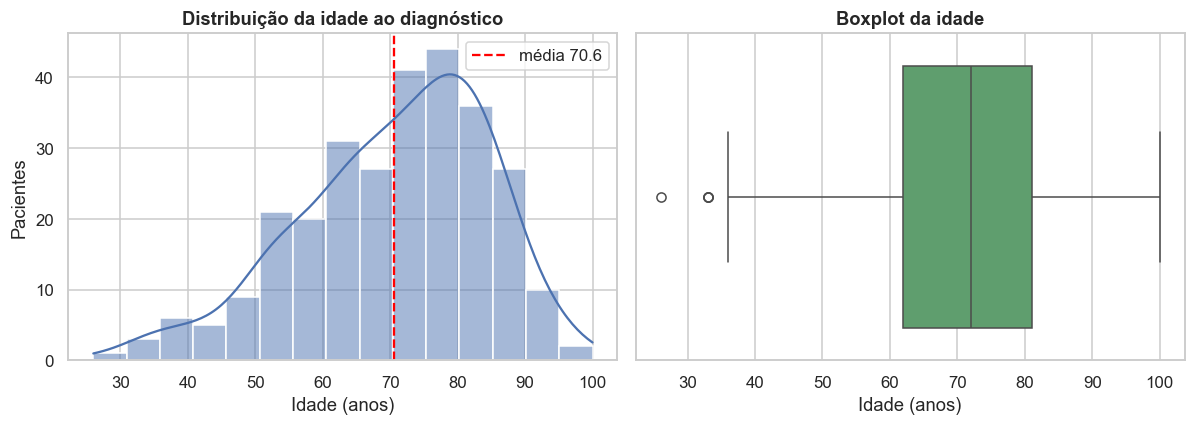

In [13]:
idade = df_paciente["idade"].dropna()
desc = idade.describe()[["count","mean","std","min","50%","max"]]
desc.index = ["n","média","desvio","mínimo","mediana","máximo"]
print(desc.round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(idade, bins=15, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(idade.mean(), color="red", ls="--", label=f"média {idade.mean():.1f}")
axes[0].set(title="Distribuição da idade ao diagnóstico", xlabel="Idade (anos)", ylabel="Pacientes")
axes[0].legend()
sns.boxplot(x=idade, ax=axes[1], color="#55A868")
axes[1].set(title="Boxplot da idade", xlabel="Idade (anos)")
plt.tight_layout(); salvar_fig("01_idade.png"); plt.show()

### 4.2. Sexo

             n     %
sexo                
Masculino  170  59.6
Feminino   115  40.4


[figura] 02_sexo.png


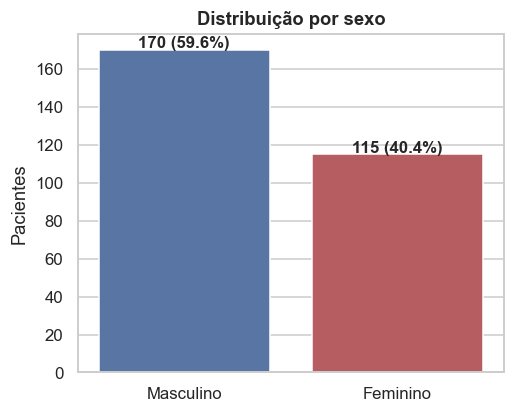

In [14]:
sx = df_paciente["sexo"].value_counts()
pct = (sx/sx.sum()*100).round(1)
print(pd.DataFrame({"n": sx, "%": pct}))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=sx.index, y=sx.values, ax=ax, palette=["#4C72B0","#C44E52"])
for i,(v,p) in enumerate(zip(sx.values, pct.values)):
    ax.text(i, v+1, f"{v} ({p}%)", ha="center", fontweight="bold")
ax.set(title="Distribuição por sexo", xlabel="", ylabel="Pacientes")
salvar_fig("02_sexo.png"); plt.show()

### 4.3. Profissão (agrupada por setor)

                          n     %
profissao_grupo                  
Agrícola/rural          131  46.0
Comércio/serviços        33  11.6
Do lar                   28   9.8
NaN                      26   9.1
Aposentado(a)            24   8.4
Construção/braçal        23   8.1
Saúde/educação/público   19   6.7
Desempregado              1   0.4


[figura] 03_profissao.png


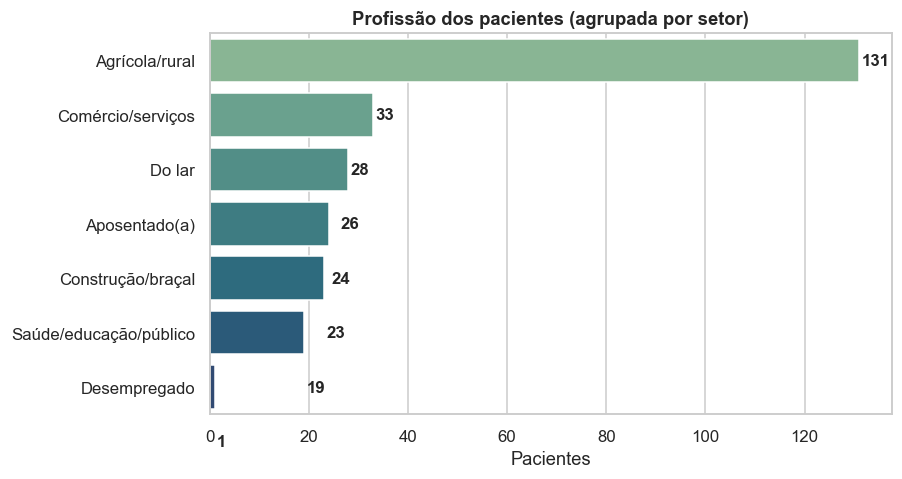

In [15]:
GRUPOS_PROF = {
    "Agrícola/rural":          ["trabalhador agricola","lavrador","salineiro","pescador"],
    "Aposentado(a)":           ["aposentado","pensionista"],
    "Do lar":                  ["do lar"],
    "Construção/braçal":       ["carpinteiro","marceneiro","eletricista","trabalhador de obras",
                                "trabalhador de concreto armado","soldador","pintor",
                                "trabalhador bracal","mecanico","operador de maquinas"],
    "Comércio/serviços":       ["comerciante","motorista","atendente","cozinheira","domestica",
                                "domestica/copeira","vendedor","cabeleireira","lavadeira","asg",
                                "vigilante","seguranca","autonomo","autonoma","gerente de empresa"],
    "Saúde/educação/público":  ["professor","professora","medico","enfermeira",
                                "auxiliar de enfermagem","tec enfermagem","policial",
                                "funcionaria publica","funcionario publico","advogado"],
    "Desempregado":            ["desempregado"],
}
mapa_grupo = {v:g for g,vs in GRUPOS_PROF.items() for v in vs}
df_paciente["profissao_grupo"] = df_paciente["profissao"].map(mapa_grupo)
df_paciente.loc[df_paciente["profissao"].notna() & df_paciente["profissao_grupo"].isna(),
                "profissao_grupo"] = "Outros"
df_lesao["profissao_grupo"] = df_lesao["profissao"].map(mapa_grupo)
df_lesao.loc[df_lesao["profissao"].notna() & df_lesao["profissao_grupo"].isna(),
             "profissao_grupo"] = "Outros"

pg = df_paciente["profissao_grupo"].value_counts(dropna=False)
print(pd.DataFrame({"n": pg, "%": (pg/pg.sum()*100).round(1)}))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(y=pg.index.astype(str), x=pg.values, ax=ax, palette="crest")
for i, v in enumerate(pg.values): ax.text(v+0.5, i, str(v), va="center", fontweight="bold")
ax.set(title="Profissão dos pacientes (agrupada por setor)", xlabel="Pacientes", ylabel="")
salvar_fig("03_profissao.png"); plt.show()

### 4.4. Etnia e estado civil

[figura] 04_etnia_estadocivil.png


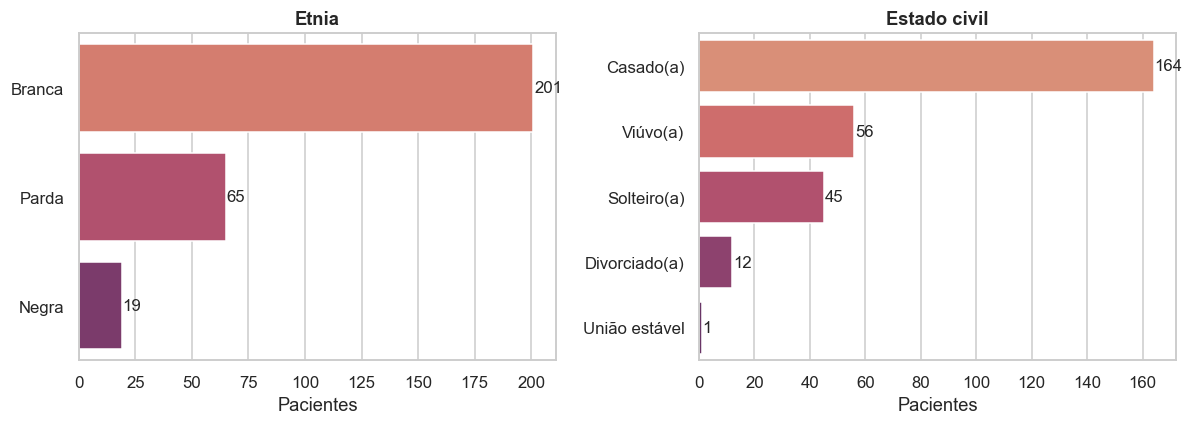

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, titulo in zip(axes, ["etnia","estado_civil"], ["Etnia","Estado civil"]):
    vc = df_paciente[col].value_counts()
    sns.barplot(y=vc.index, x=vc.values, ax=ax, palette="flare")
    for i, v in enumerate(vc.values): ax.text(v+0.3, i, str(v), va="center")
    ax.set(title=titulo, xlabel="Pacientes", ylabel="")
plt.tight_layout(); salvar_fig("04_etnia_estadocivil.png"); plt.show()

## 5. Comparação da idade entre sexos
*Análise em nível paciente.* Testes de normalidade (Shapiro-Wilk) e de
homogeneidade de variâncias (Levene) precedem a escolha entre teste t de Welch
e Mann-Whitney.

In [17]:
h = df_paciente.loc[df_paciente["sexo"]=="Masculino", "idade"].dropna()
m = df_paciente.loc[df_paciente["sexo"]=="Feminino", "idade"].dropna()

tab = pd.DataFrame({
    "n":[len(h), len(m)],
    "média":[h.mean(), m.mean()],
    "desvio":[h.std(), m.std()],
    "mediana":[h.median(), m.median()],
}, index=["Masculino","Feminino"]).round(1)
print(tab)

p_sh_h = stats.shapiro(h).pvalue; p_sh_m = stats.shapiro(m).pvalue
p_lev = stats.levene(h, m).pvalue
print(f"\nShapiro-Wilk: Masculino p={p_sh_h:.3f} | Feminino p={p_sh_m:.3f}")
print(f"Levene: p={p_lev:.3f}")

if p_sh_h > 0.05 and p_sh_m > 0.05:
    est, pval = stats.ttest_ind(h, m, equal_var=False)
    sp = np.sqrt(((len(h)-1)*h.std()**2 + (len(m)-1)*m.std()**2)/(len(h)+len(m)-2))
    efeito = (h.mean()-m.mean())/sp
    teste = "Teste t de Welch"; metr = "d de Cohen"
    print(f"\n{teste}: t={est:.3f}, p={pval:.4f} | {metr}={efeito:.3f}")
else:
    est, pval = stats.mannwhitneyu(h, m, alternative="two-sided")
    efeito = 1 - 2*est/(len(h)*len(m))
    teste = "Mann-Whitney"; metr = "r rank-biserial"
    print(f"\n{teste}: U={est:.1f}, p={pval:.4f} | {metr}={efeito:.3f}")
print("Diferença significativa (α=0,05)?", "SIM" if pval < 0.05 else "NÃO")

RESULTADOS.append({"bloco":"Descritivo","codigo":"D1",
                   "cruzamento":"Idade × Sexo (pacientes)",
                   "n": len(h)+len(m), "teste": teste,
                   "estatistica": round(float(est),3),
                   "p_valor": round(float(pval),4),
                   "efeito": round(float(efeito),3),
                   "significativo": "SIM" if pval < 0.05 else "não"})

             n  média  desvio  mediana
Masculino  168   69.6    13.9     72.0
Feminino   115   72.1    14.1     75.0

Shapiro-Wilk: Masculino p=0.002 | Feminino p=0.001
Levene: p=0.660

Mann-Whitney: U=8484.0, p=0.0820 | r rank-biserial=0.122
Diferença significativa (α=0,05)? NÃO


[figura] 05_idade_por_sexo.png


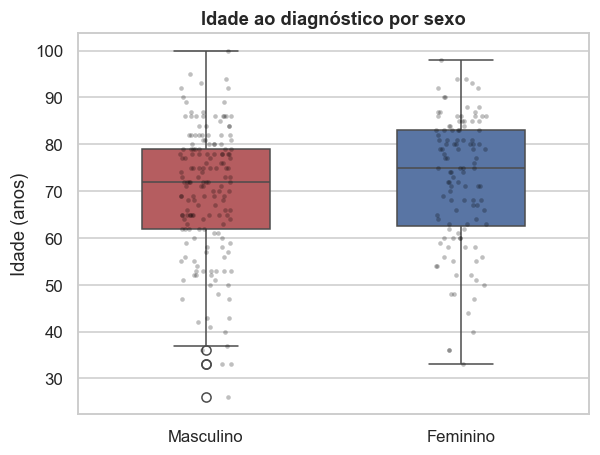

In [18]:
fig, ax = plt.subplots(figsize=(6, 4.5))
dados = df_paciente.dropna(subset=["idade","sexo"])
sns.boxplot(data=dados, x="sexo", y="idade", ax=ax,
            palette=["#C44E52","#4C72B0"], width=.5)
sns.stripplot(data=dados, x="sexo", y="idade", ax=ax,
              color="black", alpha=.25, size=3)
ax.set(title="Idade ao diagnóstico por sexo", xlabel="", ylabel="Idade (anos)")
salvar_fig("05_idade_por_sexo.png"); plt.show()

## 6. Função genérica de análise cruzada

Esta função padroniza todas as análises seguintes: monta a tabela de
contingência (ou descritivo agrupado), aplica o teste apropriado, registra os
resultados na tabela-mestre e gera o gráfico correspondente. Suporta dois
modos:

- **Categórica × categórica:** qui-quadrado de Pearson com V de Cramer; em
  tabelas 2×2, também o exato de Fisher.
- **Categórica × contínua:** Mann-Whitney (2 grupos) ou Kruskal-Wallis (≥ 3),
  com tamanho de efeito apropriado.

In [19]:
def cramer_v(ct):
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum(); r, k = ct.shape
    return float(np.sqrt(chi2/(n*(min(r,k)-1)))) if min(r,k) > 1 else np.nan

def analisa(bloco, codigo, lin, col, titulo, arquivo, data=None,
            ordem_lin=None, ordem_col=None, continua=False):
    if data is None: data = df_lesao
    sub = data.dropna(subset=[lin, col])
    n = len(sub)
    if n < 5:
        print(f"[{codigo}] {titulo}: n={n} insuficiente.")
        RESULTADOS.append({"bloco":bloco,"codigo":codigo,"cruzamento":titulo,
                           "n":n,"teste":"-","estatistica":np.nan,"p_valor":np.nan,
                           "efeito":np.nan,"significativo":""})
        return None

    print(f"\n=== [{codigo}] {titulo} ===  (n = {n})")

    if continua:
        grupos = [sub.loc[sub[lin]==g, col].dropna()
                  for g in sub[lin].unique() if (sub[lin]==g).sum() >= 2]
        if len(grupos) < 2:
            print("Grupos insuficientes."); return None
        desc = sub.groupby(lin, observed=True)[col].agg(
            ["count","mean","std","median",
             lambda x: x.quantile(.25), lambda x: x.quantile(.75)])
        desc.columns = ["n","média","desvio","mediana","q1","q3"]
        print(desc.round(2))
        if len(grupos) == 2:
            est, p = stats.mannwhitneyu(grupos[0], grupos[1], alternative="two-sided")
            n1, n2 = len(grupos[0]), len(grupos[1])
            efeito = 1 - 2*est/(n1*n2)
            teste = "Mann-Whitney"
            print(f"\n{teste}: U={est:.1f}, p={p:.4f} | r={efeito:.3f}")
        else:
            est, p = stats.kruskal(*grupos)
            efeito = est/(n - 1)
            teste = "Kruskal-Wallis"
            print(f"\n{teste}: H={est:.3f}, p={p:.4f} | η²≈{efeito:.3f}")

        fig, ax = plt.subplots(figsize=(8.5, 4.5))
        ordem = ordem_lin or list(sub[lin].dropna().unique())
        sns.boxplot(data=sub, x=lin, y=col, order=ordem, ax=ax,
                    palette="crest", width=.55)
        sns.stripplot(data=sub, x=lin, y=col, order=ordem, ax=ax,
                      color="black", alpha=.25, size=2)
        ax.set(title=f"{titulo}\n{teste}: p={p:.4f}", xlabel="", ylabel=col)
        plt.xticks(rotation=15, ha="right")
        salvar_fig(arquivo); plt.show()
    else:
        ct = pd.crosstab(sub[lin], sub[col])
        if ordem_lin: ct = ct.reindex([x for x in ordem_lin if x in ct.index])
        if ordem_col: ct = ct[[x for x in ordem_col if x in ct.columns]]
        print("Frequências:"); print(ct)
        pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
        print("\n% por linha:"); print(pct)
        chi2, p, dof, esp = stats.chi2_contingency(ct)
        v = cramer_v(ct)
        if ct.shape == (2,2):
            _, pf = stats.fisher_exact(ct)
            print(f"\nQui²={chi2:.3f}, gl={dof}, p={p:.4f} | Fisher p={pf:.4f} | V Cramer={v:.3f}")
            p_uso, teste, est_uso = pf, "Fisher (2x2)", chi2
        else:
            print(f"\nQui²={chi2:.3f}, gl={dof}, p={p:.4f} | V Cramer={v:.3f}")
            if esp.min() < 5:
                print(f"Aviso: menor frequência esperada = {esp.min():.2f}.")
            p_uso, teste, est_uso = p, f"Qui-quadrado (gl={dof})", chi2
        efeito = v

        fig, ax = plt.subplots(figsize=(9, 4.5))
        pct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set(title=f"{titulo}\n{teste}: p={p_uso:.4f}",
               xlabel="", ylabel="% por linha")
        ax.legend(title=col, bbox_to_anchor=(1.02,1), loc="upper left")
        plt.xticks(rotation=20, ha="right")
        salvar_fig(arquivo); plt.show()
        est = est_uso; p = p_uso

    sig = "SIM" if (p is not None and p < 0.05) else "não"
    print(f"Significativo (α=0,05)? {sig.upper()}")
    RESULTADOS.append({"bloco":bloco,"codigo":codigo,"cruzamento":titulo,"n":n,
                       "teste": teste,
                       "estatistica": round(float(est),3) if est==est else np.nan,
                       "p_valor": round(float(p),4) if p==p else np.nan,
                       "efeito": round(float(efeito),3) if efeito==efeito else np.nan,
                       "significativo": sig})

print("Função pronta.")

Função pronta.


## 7. Margens comprometidas × Reincidência

Avalia-se se o comprometimento de margens (lateral ou profunda) associa-se
à reincidência do tumor.


=== [M1] Margens × Reincidência ===  (n = 409)
Frequências:
reincidencia         Não  Sim
margem_comprometida          
Livre                348   11
Comprometida          41    9

% por linha:
reincidencia          Não   Sim
margem_comprometida            
Livre                96.9   3.1
Comprometida         82.0  18.0



Qui²=17.962, gl=1, p=0.0000 | Fisher p=0.0002 | V Cramer=0.227


[figura] 07_margens_x_reincidencia.png


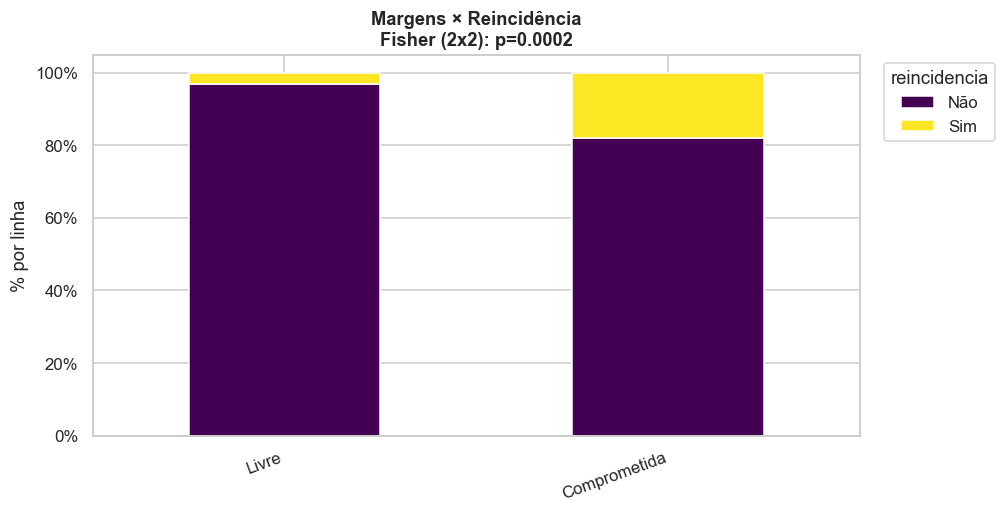

Significativo (α=0,05)? SIM


In [20]:
analisa("Margens","M1","margem_comprometida","reincidencia",
        "Margens × Reincidência", "07_margens_x_reincidencia.png",
        ordem_lin=["Livre","Comprometida"], ordem_col=["Não","Sim"])

## 8. Bloco A — Estado civil × saúde (estratificado por sexo)

Avalia-se se pacientes sem companheiro(a) apresentam doença mais avançada
(profundidade de infiltração, tamanho da lesão, ulceração, margens
comprometidas). A análise é estratificada por sexo.

In [21]:
ORD_EC = ["Com companheiro(a)", "Sem companheiro(a)"]
h_les = df_lesao[df_lesao["sexo"]=="Masculino"].copy()
m_les = df_lesao[df_lesao["sexo"]=="Feminino"].copy()
print(f"Lesões em homens: {len(h_les)}  |  Lesões em mulheres: {len(m_les)}")

Lesões em homens: 252  |  Lesões em mulheres: 167



=== [A1] Homens — Estado civil × Grau de infiltração ===  (n = 236)
Frequências:
grau_infiltracao    1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
estado_civil_grupo                                                          
Com companheiro(a)        14                  93                       33   
Sem companheiro(a)        16                  62                       11   

grau_infiltracao    4. Estruturas profundas  
estado_civil_grupo                           
Com companheiro(a)                        5  
Sem companheiro(a)                        2  

% por linha:
grau_infiltracao    1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
estado_civil_grupo                                                          
Com companheiro(a)       9.7                64.1                     22.8   
Sem companheiro(a)      17.6                68.1                     12.1   

grau_infiltracao    4. Estruturas profundas  
estado_civil_grupo                           
Com compan

[figura] A1_h_civil_x_grau.png


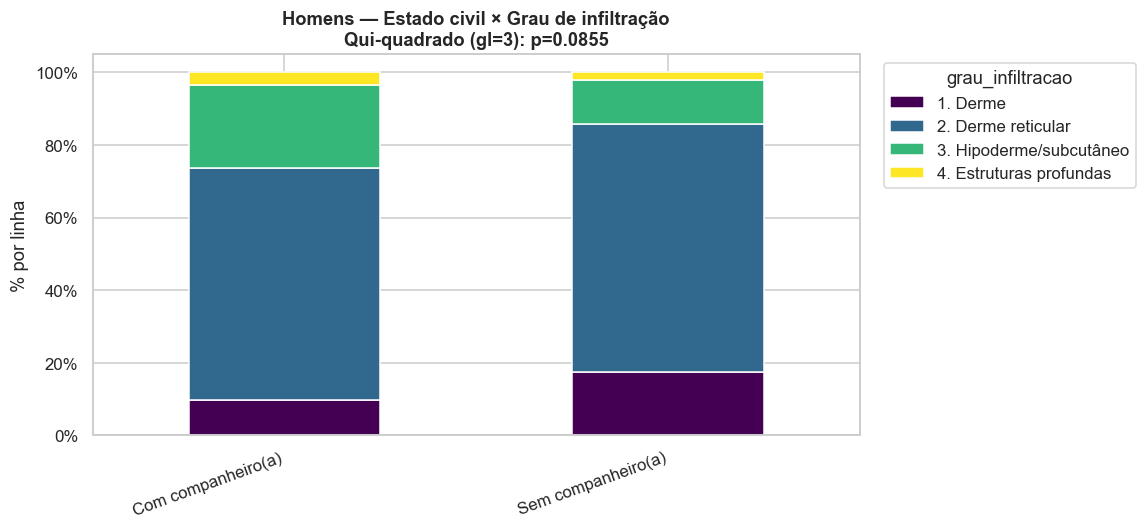

Significativo (α=0,05)? NÃO


In [22]:
analisa("A","A1","estado_civil_grupo","grau_infiltracao",
        "Homens — Estado civil × Grau de infiltração",
        "A1_h_civil_x_grau.png", data=h_les, ordem_lin=ORD_EC, ordem_col=ORDEM_GRAU)


=== [A2] Homens — Estado civil × Tamanho da lesão (cm) ===  (n = 248)


                      n  média  desvio  mediana   q1   q3
estado_civil_grupo                                       
Com companheiro(a)  153   1.66    1.32      1.2  0.9  2.0
Sem companheiro(a)   95   1.86    1.38      1.4  1.0  2.3

Mann-Whitney: U=8144.0, p=0.1099 | r=-0.121


[figura] A2_h_civil_x_tamanho.png


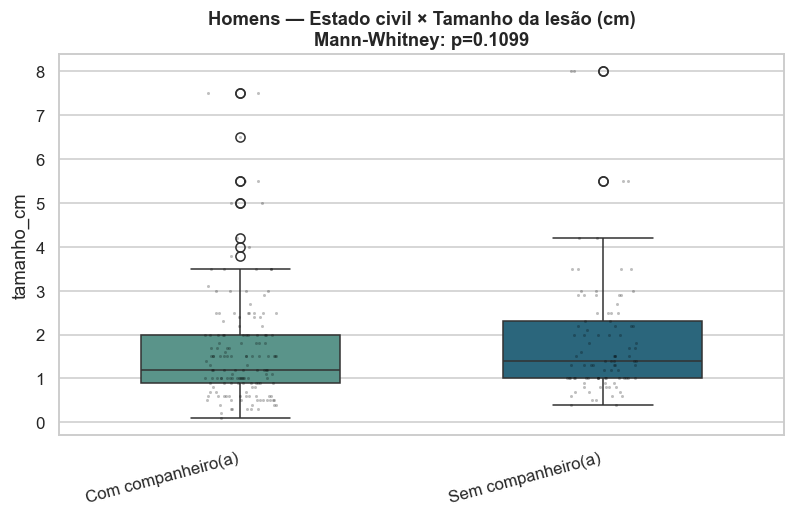

Significativo (α=0,05)? NÃO


In [23]:
analisa("A","A2","estado_civil_grupo","tamanho_cm",
        "Homens — Estado civil × Tamanho da lesão (cm)",
        "A2_h_civil_x_tamanho.png", data=h_les, ordem_lin=ORD_EC, continua=True)


=== [A3] Homens — Estado civil × Ulceração ===  (n = 246)
Frequências:
ulceracao           Não  Sim
estado_civil_grupo          
Com companheiro(a)   46  105
Sem companheiro(a)   27   68

% por linha:
ulceracao            Não   Sim
estado_civil_grupo            
Com companheiro(a)  30.5  69.5
Sem companheiro(a)  28.4  71.6

Qui²=0.039, gl=1, p=0.8430 | Fisher p=0.7756 | V Cramer=0.022


[figura] A3_h_civil_x_ulceracao.png


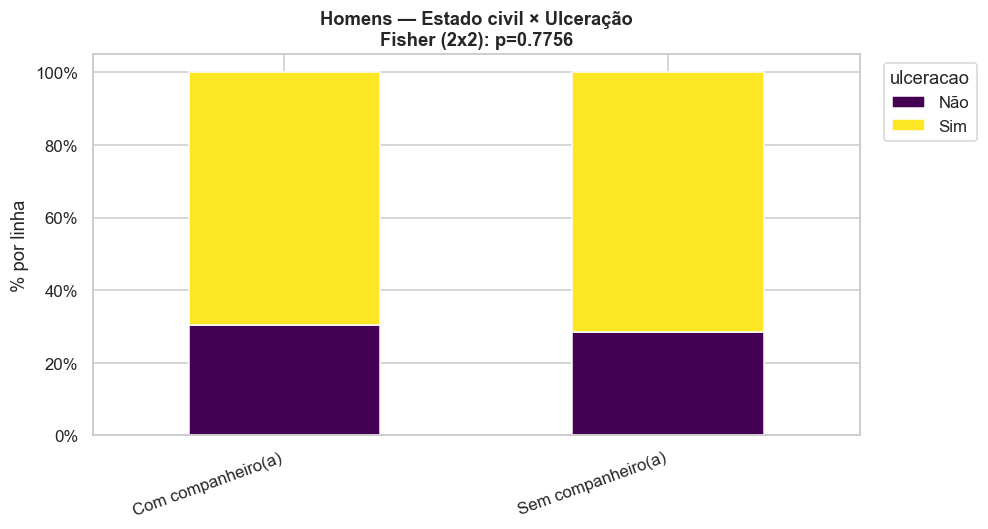

Significativo (α=0,05)? NÃO


In [24]:
analisa("A","A3","estado_civil_grupo","ulceracao",
        "Homens — Estado civil × Ulceração",
        "A3_h_civil_x_ulceracao.png", data=h_les,
        ordem_lin=ORD_EC, ordem_col=["Não","Sim"])


=== [A4] Homens — Estado civil × Margens comprometidas ===  (n = 245)
Frequências:
margem_comprometida  Livre  Comprometida
estado_civil_grupo                      
Com companheiro(a)     128            23
Sem companheiro(a)      85             9

% por linha:
margem_comprometida  Livre  Comprometida
estado_civil_grupo                      
Com companheiro(a)    84.8          15.2
Sem companheiro(a)    90.4           9.6

Qui²=1.173, gl=1, p=0.2788 | Fisher p=0.2442 | V Cramer=0.082


[figura] A4_h_civil_x_margens.png


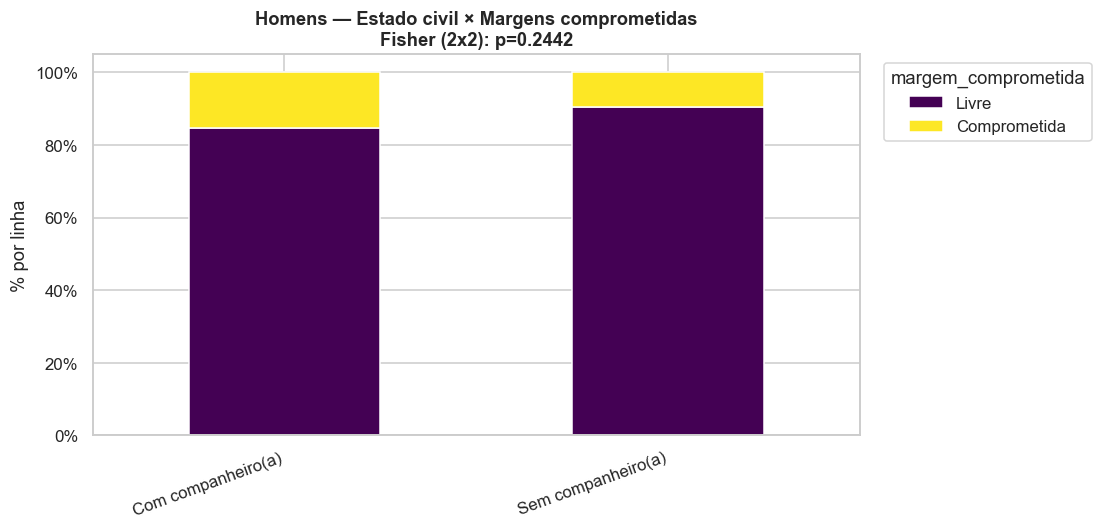

Significativo (α=0,05)? NÃO


In [25]:
analisa("A","A4","estado_civil_grupo","margem_comprometida",
        "Homens — Estado civil × Margens comprometidas",
        "A4_h_civil_x_margens.png", data=h_les,
        ordem_lin=ORD_EC, ordem_col=["Livre","Comprometida"])


=== [A5] Mulheres — Estado civil × Grau de infiltração ===  (n = 147)
Frequências:
grau_infiltracao    1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
estado_civil_grupo                                                          
Com companheiro(a)        14                  55                        8   
Sem companheiro(a)        10                  45                        8   

grau_infiltracao    4. Estruturas profundas  
estado_civil_grupo                           
Com companheiro(a)                        1  
Sem companheiro(a)                        6  

% por linha:
grau_infiltracao    1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
estado_civil_grupo                                                          
Com companheiro(a)      17.9                70.5                     10.3   
Sem companheiro(a)      14.5                65.2                     11.6   

grau_infiltracao    4. Estruturas profundas  
estado_civil_grupo                           
Com comp

[figura] A5_m_civil_x_grau.png


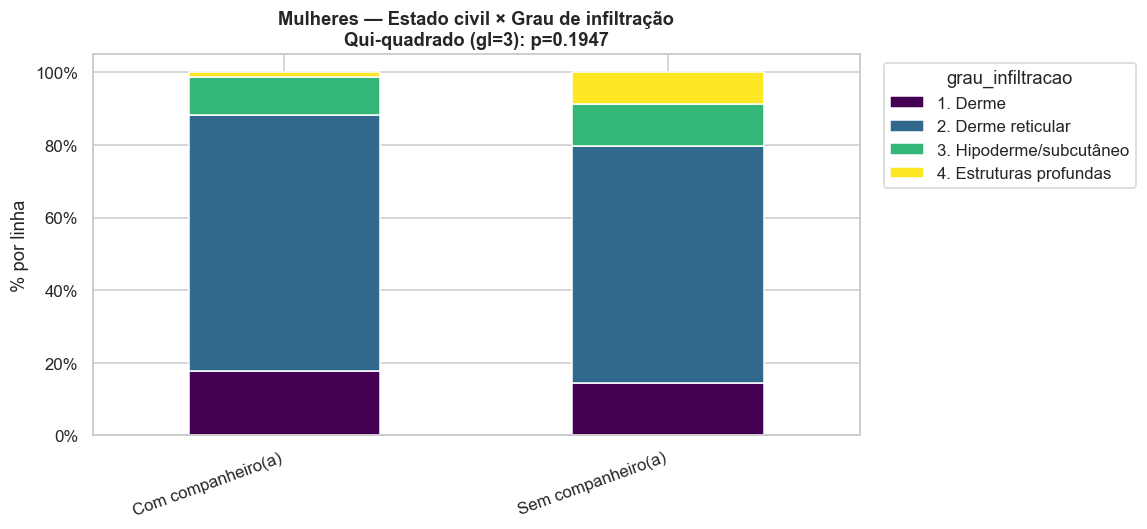

Significativo (α=0,05)? NÃO


In [26]:
analisa("A","A5","estado_civil_grupo","grau_infiltracao",
        "Mulheres — Estado civil × Grau de infiltração",
        "A5_m_civil_x_grau.png", data=m_les, ordem_lin=ORD_EC, ordem_col=ORDEM_GRAU)


=== [A6] Mulheres — Estado civil × Tamanho da lesão (cm) ===  (n = 163)
                     n  média  desvio  mediana   q1   q3
estado_civil_grupo                                      
Com companheiro(a)  84   1.28    0.96      1.0  0.8  1.5
Sem companheiro(a)  79   1.26    0.71      1.1  0.8  1.5

Mann-Whitney: U=3126.5, p=0.5240 | r=0.058


[figura] A6_m_civil_x_tamanho.png


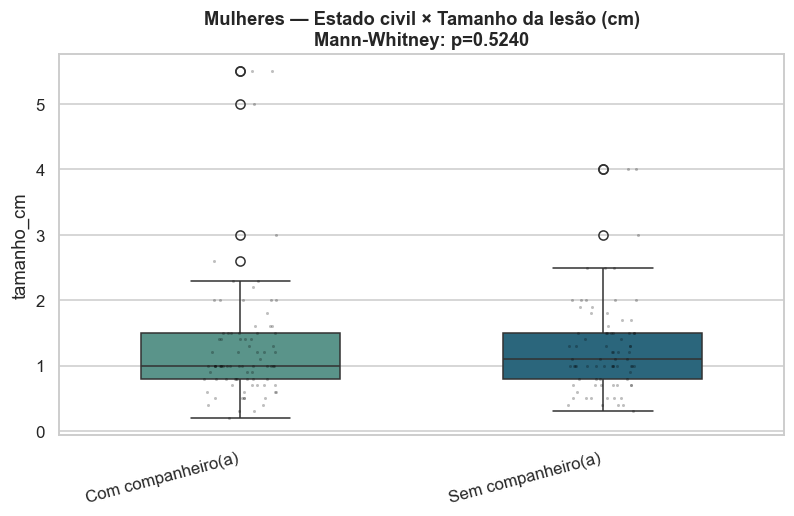

Significativo (α=0,05)? NÃO


In [27]:
analisa("A","A6","estado_civil_grupo","tamanho_cm",
        "Mulheres — Estado civil × Tamanho da lesão (cm)",
        "A6_m_civil_x_tamanho.png", data=m_les, ordem_lin=ORD_EC, continua=True)


=== [A7] Mulheres — Estado civil × Ulceração ===  (n = 162)
Frequências:
ulceracao           Não  Sim
estado_civil_grupo          
Com companheiro(a)   31   52
Sem companheiro(a)   41   38

% por linha:
ulceracao            Não   Sim
estado_civil_grupo            
Com companheiro(a)  37.3  62.7
Sem companheiro(a)  51.9  48.1

Qui²=2.906, gl=1, p=0.0883 | Fisher p=0.0818 | V Cramer=0.146


[figura] A7_m_civil_x_ulceracao.png


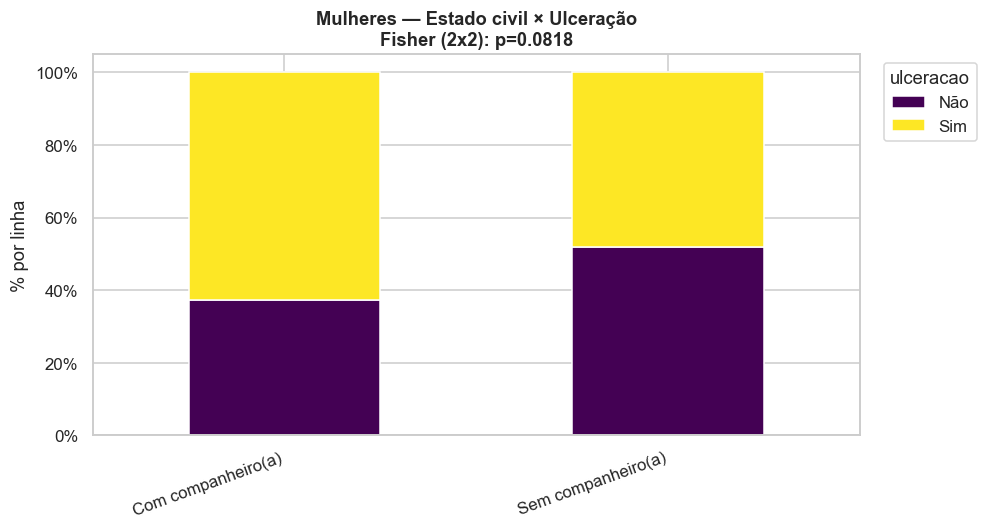

Significativo (α=0,05)? NÃO


In [28]:
analisa("A","A7","estado_civil_grupo","ulceracao",
        "Mulheres — Estado civil × Ulceração",
        "A7_m_civil_x_ulceracao.png", data=m_les,
        ordem_lin=ORD_EC, ordem_col=["Não","Sim"])


=== [A8] Mulheres — Estado civil × Margens comprometidas ===  (n = 164)
Frequências:
margem_comprometida  Livre  Comprometida
estado_civil_grupo                      
Com companheiro(a)      74            11
Sem companheiro(a)      69            10

% por linha:
margem_comprometida  Livre  Comprometida
estado_civil_grupo                      
Com companheiro(a)    87.1          12.9
Sem companheiro(a)    87.3          12.7

Qui²=0.000, gl=1, p=1.0000 | Fisher p=1.0000 | V Cramer=0.004


[figura] A8_m_civil_x_margens.png


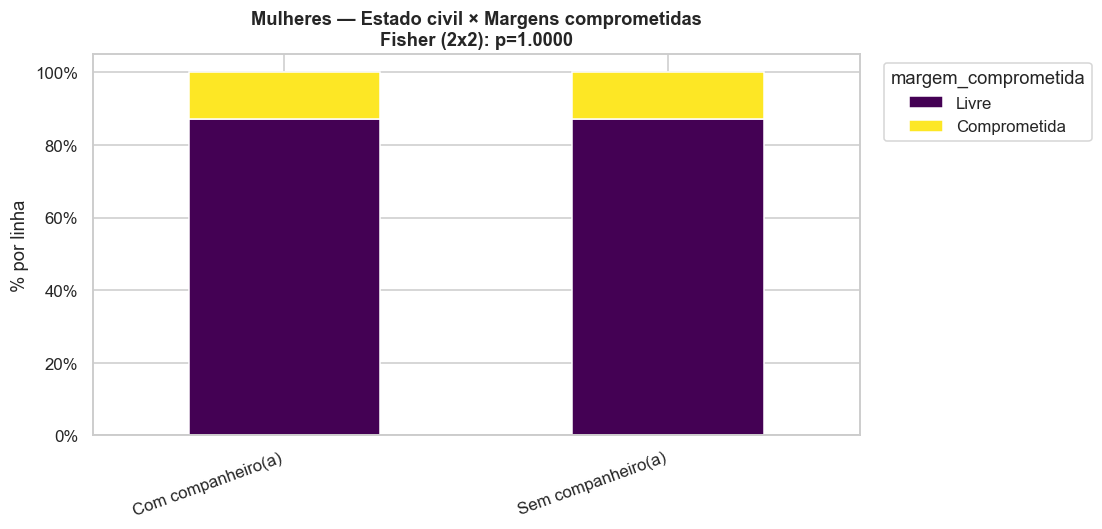

Significativo (α=0,05)? NÃO


In [29]:
analisa("A","A8","estado_civil_grupo","margem_comprometida",
        "Mulheres — Estado civil × Margens comprometidas",
        "A8_m_civil_x_margens.png", data=m_les,
        ordem_lin=ORD_EC, ordem_col=["Livre","Comprometida"])

## 9. Bloco B — Faixa etária × marcadores de agressividade

Compara-se o comportamento clínico-patológico do tumor entre pacientes com
até 40 anos e acima de 40 anos. *Análise em nível lesão (a idade considerada
é a do diagnóstico de cada lesão).*

Atenção: apenas 23 lesões correspondem a pacientes com até 40 anos, o que
limita o poder estatístico desses testes.


=== [B1] Faixa etária × Margens comprometidas ===  (n = 414)
Frequências:
margem_comprometida  Livre  Comprometida
faixa_etaria                            
≤ 40 anos               22             1
> 40 anos              339            52

% por linha:
margem_comprometida  Livre  Comprometida
faixa_etaria                            
≤ 40 anos             95.7           4.3
> 40 anos             86.7          13.3

Qui²=0.860, gl=1, p=0.3536 | Fisher p=0.3364 | V Cramer=0.061


[figura] B1_idade_x_margens.png


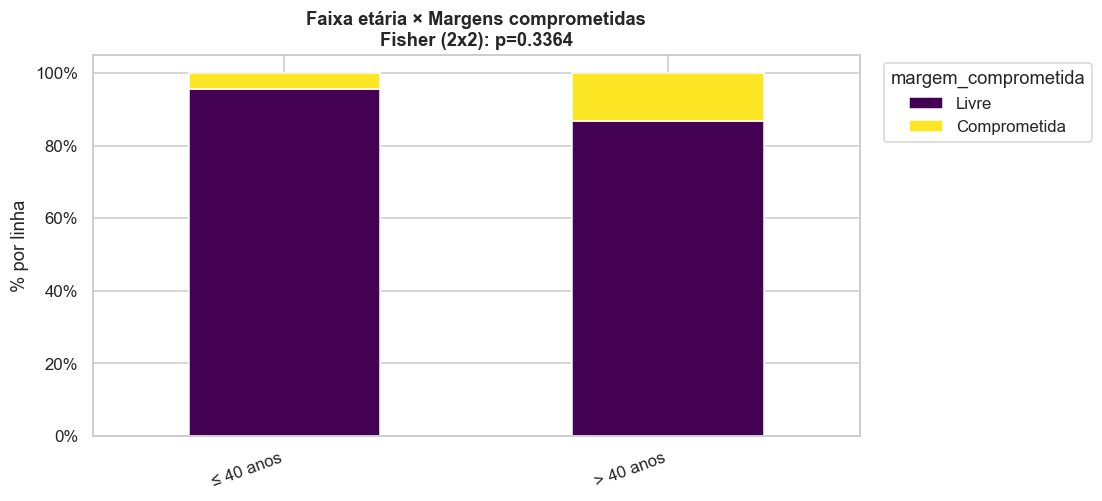

Significativo (α=0,05)? NÃO


In [30]:
ORD_FE = ["≤ 40 anos", "> 40 anos"]
analisa("B","B1","faixa_etaria","margem_comprometida",
        "Faixa etária × Margens comprometidas", "B1_idade_x_margens.png",
        ordem_lin=ORD_FE, ordem_col=["Livre","Comprometida"])


=== [B2] Faixa etária × Invasão perineural ===  (n = 413)
Frequências:
inv_perineural  Não  Sim
faixa_etaria            
≤ 40 anos        20    3
> 40 anos       373   17

% por linha:
inv_perineural   Não   Sim
faixa_etaria              
≤ 40 anos       87.0  13.0
> 40 anos       95.6   4.4

Qui²=1.920, gl=1, p=0.1659 | Fisher p=0.0923 | V Cramer=0.093


[figura] B2_idade_x_perineural.png


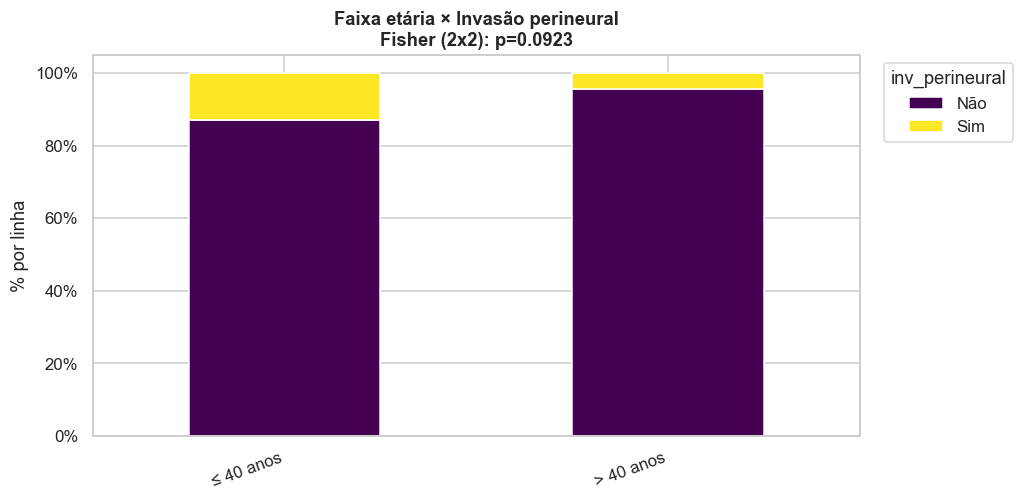

Significativo (α=0,05)? NÃO


In [31]:
analisa("B","B2","faixa_etaria","inv_perineural",
        "Faixa etária × Invasão perineural", "B2_idade_x_perineural.png",
        ordem_lin=ORD_FE, ordem_col=["Não","Sim"])


=== [B3] Faixa etária × Invasão linfovascular ===  (n = 198)
Frequências:
inv_linfovascular  Não
faixa_etaria          
≤ 40 anos           11
> 40 anos          187

% por linha:
inv_linfovascular    Não
faixa_etaria            
≤ 40 anos          100.0
> 40 anos          100.0

Qui²=0.000, gl=0, p=1.0000 | V Cramer=nan


[figura] B3_idade_x_linfovascular.png


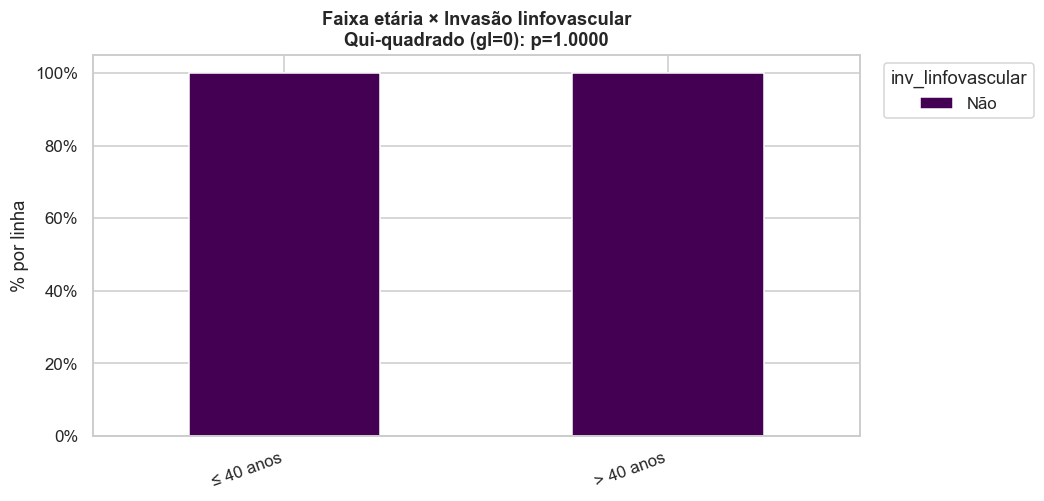

Significativo (α=0,05)? NÃO


In [32]:
analisa("B","B3","faixa_etaria","inv_linfovascular",
        "Faixa etária × Invasão linfovascular", "B3_idade_x_linfovascular.png",
        ordem_lin=ORD_FE)


=== [B4] Faixa etária × Ulceração ===  (n = 413)
Frequências:
ulceracao     Não  Sim
faixa_etaria          
≤ 40 anos       6   16
> 40 anos     140  251

% por linha:
ulceracao      Não   Sim
faixa_etaria            
≤ 40 anos     27.3  72.7
> 40 anos     35.8  64.2

Qui²=0.343, gl=1, p=0.5583 | Fisher p=0.4971 | V Cramer=0.040


[figura] B4_idade_x_ulceracao.png


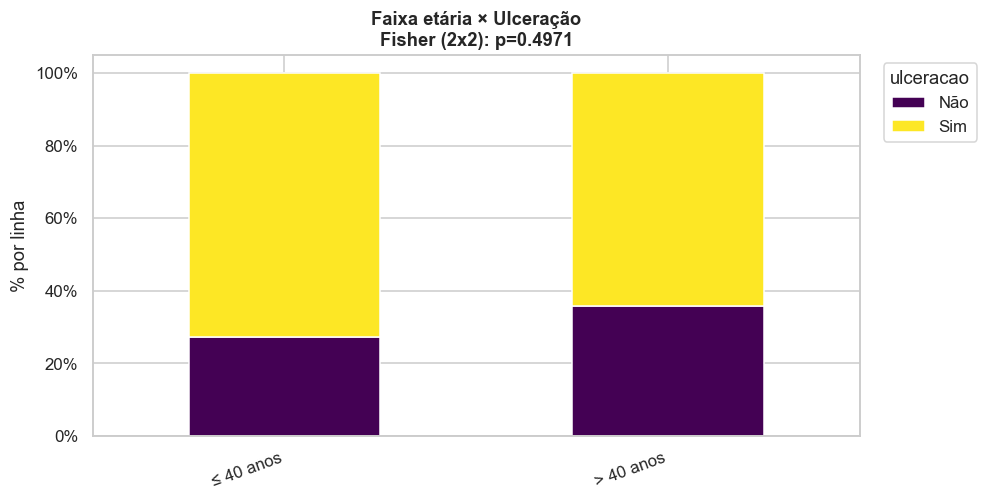

Significativo (α=0,05)? NÃO


In [33]:
analisa("B","B4","faixa_etaria","ulceracao",
        "Faixa etária × Ulceração", "B4_idade_x_ulceracao.png",
        ordem_lin=ORD_FE, ordem_col=["Não","Sim"])


=== [B5] Faixa etária × Tamanho da lesão ===  (n = 416)
                n  média  desvio  mediana    q1   q3
faixa_etaria                                        
≤ 40 anos      23   2.75    1.91      2.3  1.55  2.9
> 40 anos     393   1.49    1.10      1.2  0.80  1.8

Mann-Whitney: U=2084.5, p=0.0000 | r=0.539


[figura] B5_idade_x_tamanho.png


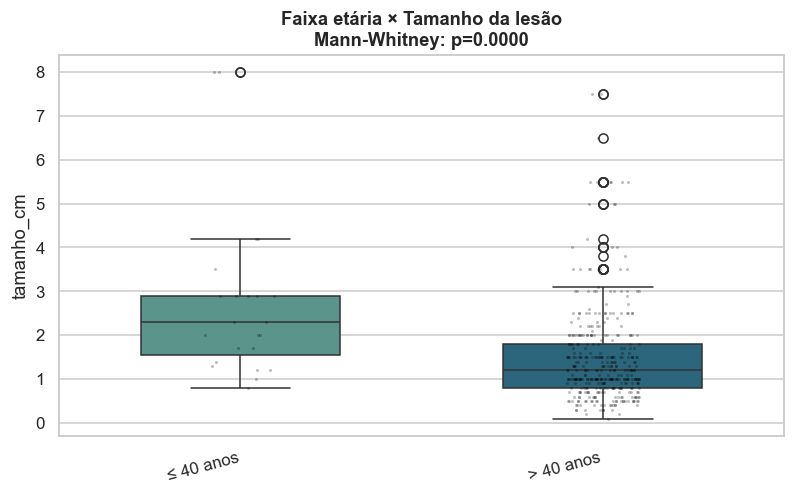

Significativo (α=0,05)? SIM


In [34]:
analisa("B","B5","faixa_etaria","tamanho_cm",
        "Faixa etária × Tamanho da lesão", "B5_idade_x_tamanho.png",
        ordem_lin=ORD_FE, continua=True)


=== [B6] Faixa etária × Grau de infiltração ===  (n = 387)
Frequências:
grau_infiltracao  1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
faixa_etaria                                                              
≤ 40 anos                1                  18                        2   
> 40 anos               53                 241                       58   

grau_infiltracao  4. Estruturas profundas  
faixa_etaria                               
≤ 40 anos                               0  
> 40 anos                              14  

% por linha:
grau_infiltracao  1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
faixa_etaria                                                              
≤ 40 anos              4.8                85.7                      9.5   
> 40 anos             14.5                65.8                     15.8   

grau_infiltracao  4. Estruturas profundas  
faixa_etaria                               
≤ 40 anos                             0.0  
> 4

[figura] B6_idade_x_grau.png


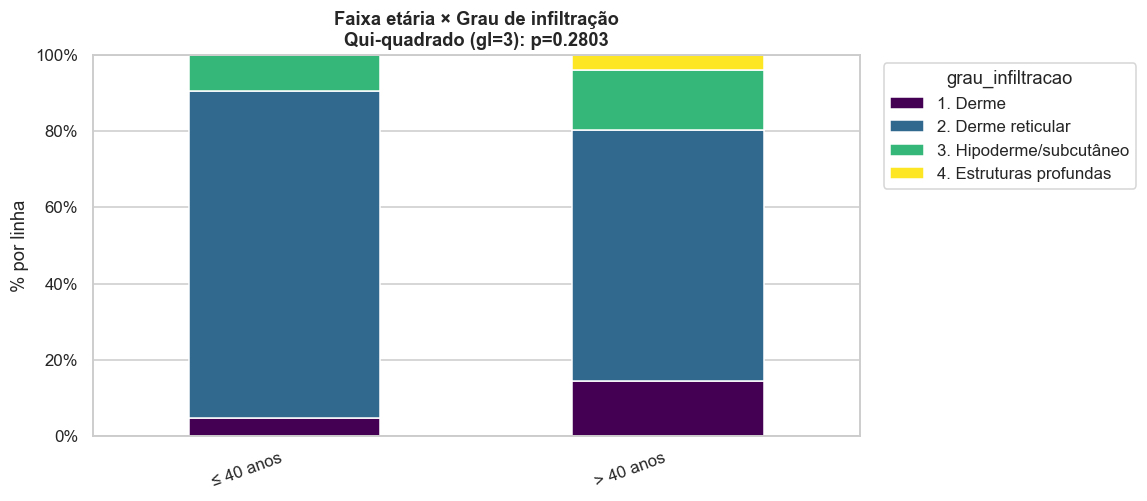

Significativo (α=0,05)? NÃO


In [35]:
analisa("B","B6","faixa_etaria","grau_infiltracao",
        "Faixa etária × Grau de infiltração", "B6_idade_x_grau.png",
        ordem_lin=ORD_FE, ordem_col=ORDEM_GRAU)


=== [B7] Faixa etária × Subtipo (3 cat) ===  (n = 417)
Frequências:
subtipo_3cat  Misto  Alto risco
faixa_etaria                   
≤ 40 anos        13          10
> 40 anos       259         135

% por linha:
subtipo_3cat  Misto  Alto risco
faixa_etaria                   
≤ 40 anos      56.5        43.5
> 40 anos      65.7        34.3

Qui²=0.458, gl=1, p=0.4986 | Fisher p=0.3749 | V Cramer=0.044


[figura] B7_idade_x_subtipo.png


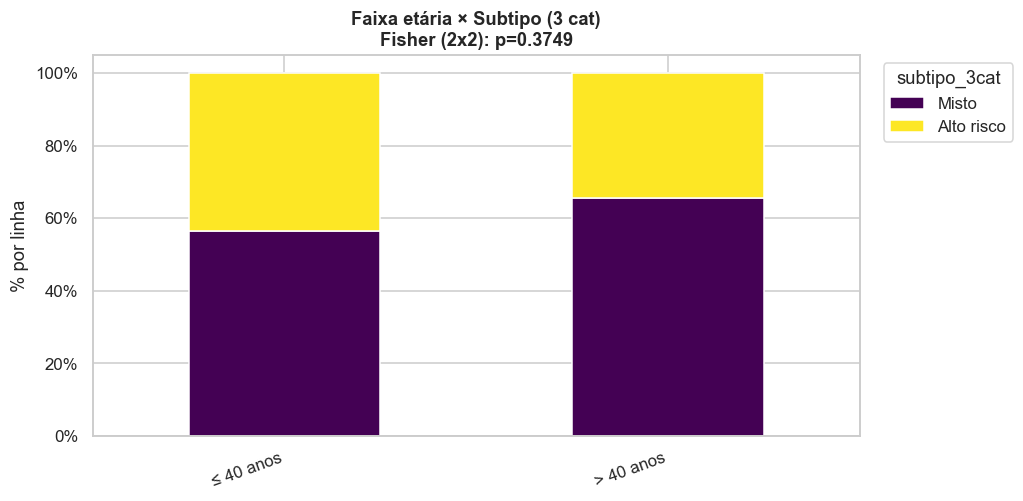

Significativo (α=0,05)? NÃO


In [36]:
analisa("B","B7","faixa_etaria","subtipo_3cat",
        "Faixa etária × Subtipo (3 cat)", "B7_idade_x_subtipo.png",
        ordem_lin=ORD_FE, ordem_col=ORDEM_SUB)

## 10. Bloco C — Exposição solar ocupacional × marcadores

Compara-se a apresentação tumoral entre pacientes com profissões com e sem
exposição solar ocupacional. Aposentado(a), autônomo(a), desempregado e
"não informado" estão excluídos por indeterminação ocupacional.


=== [C1] Exposição solar × Subtipo (3 cat) ===  (n = 322)
Frequências:
subtipo_3cat     Misto  Alto risco
exposicao_solar                   
Com exposição      140          88
Sem exposição       61          33

% por linha:
subtipo_3cat     Misto  Alto risco
exposicao_solar                   
Com exposição     61.4        38.6
Sem exposição     64.9        35.1

Qui²=0.213, gl=1, p=0.6445 | Fisher p=0.6134 | V Cramer=0.033


[figura] C1_exp_x_subtipo.png


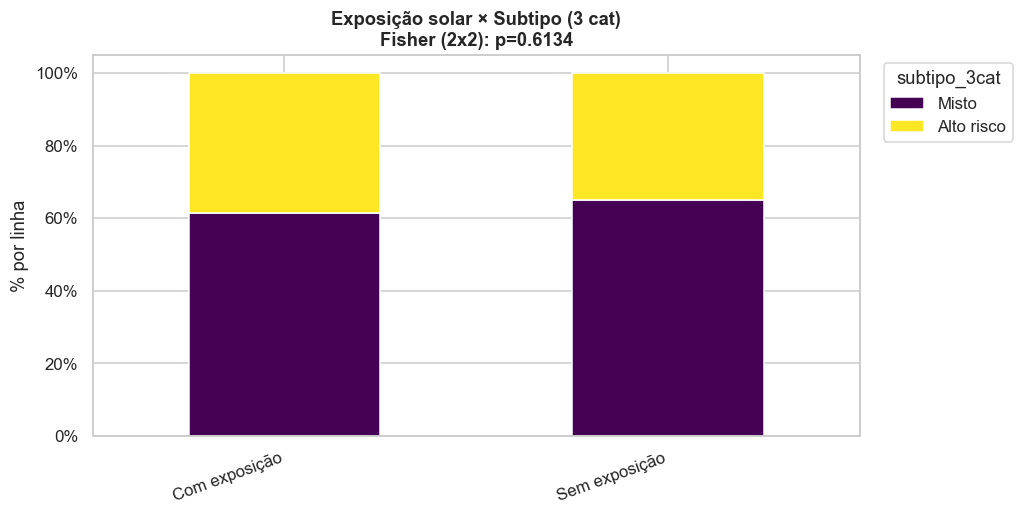

Significativo (α=0,05)? NÃO


In [37]:
ORD_EXP = ["Com exposição", "Sem exposição"]
analisa("C","C1","exposicao_solar","subtipo_3cat",
        "Exposição solar × Subtipo (3 cat)", "C1_exp_x_subtipo.png",
        ordem_lin=ORD_EXP, ordem_col=ORDEM_SUB)


=== [C2] Exposição solar × Ulceração ===  (n = 319)
Frequências:
ulceracao        Não  Sim
exposicao_solar          
Com exposição     69  157
Sem exposição     42   51

% por linha:
ulceracao         Não   Sim
exposicao_solar            
Com exposição    30.5  69.5
Sem exposição    45.2  54.8

Qui²=5.588, gl=1, p=0.0181 | Fisher p=0.0143 | V Cramer=0.140


[figura] C2_exp_x_ulceracao.png


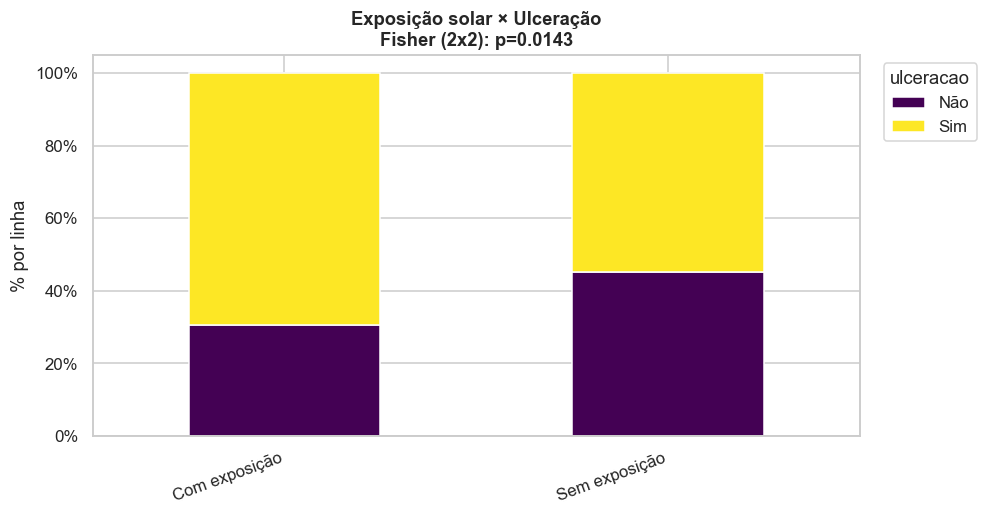

Significativo (α=0,05)? SIM


In [38]:
analisa("C","C2","exposicao_solar","ulceracao",
        "Exposição solar × Ulceração", "C2_exp_x_ulceracao.png",
        ordem_lin=ORD_EXP, ordem_col=["Não","Sim"])


=== [C3] Exposição solar × Invasão perineural ===  (n = 318)
Frequências:
inv_perineural   Não  Sim
exposicao_solar          
Com exposição    214   10
Sem exposição     88    6

% por linha:
inv_perineural    Não  Sim
exposicao_solar           
Com exposição    95.5  4.5
Sem exposição    93.6  6.4

Qui²=0.188, gl=1, p=0.6649 | Fisher p=0.5743 | V Cramer=0.040


[figura] C3_exp_x_perineural.png


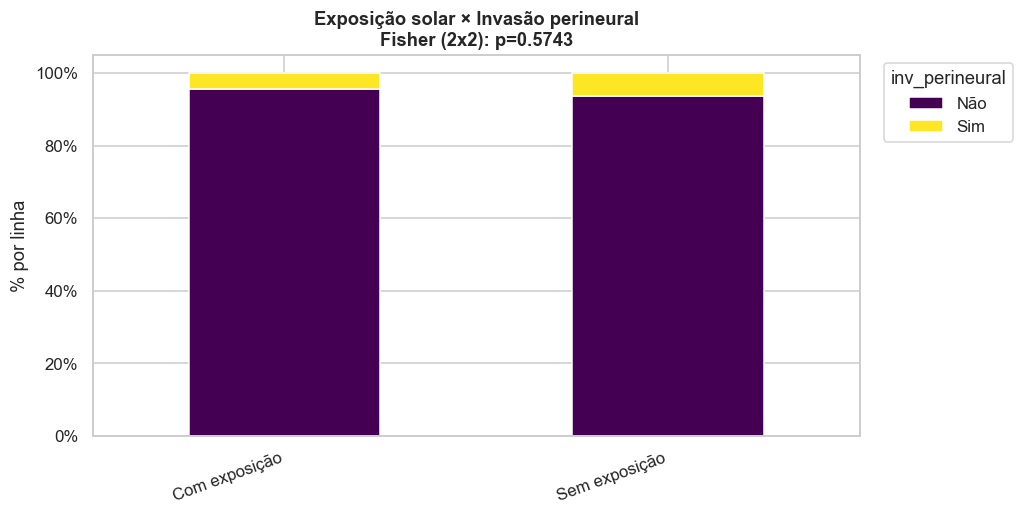

Significativo (α=0,05)? NÃO


In [39]:
analisa("C","C3","exposicao_solar","inv_perineural",
        "Exposição solar × Invasão perineural", "C3_exp_x_perineural.png",
        ordem_lin=ORD_EXP, ordem_col=["Não","Sim"])


=== [C4] Exposição solar × Invasão linfovascular ===  (n = 156)
Frequências:
inv_linfovascular  Não
exposicao_solar       
Com exposição      113
Sem exposição       43

% por linha:
inv_linfovascular    Não
exposicao_solar         
Com exposição      100.0
Sem exposição      100.0

Qui²=0.000, gl=0, p=1.0000 | V Cramer=nan


[figura] C4_exp_x_linfovascular.png


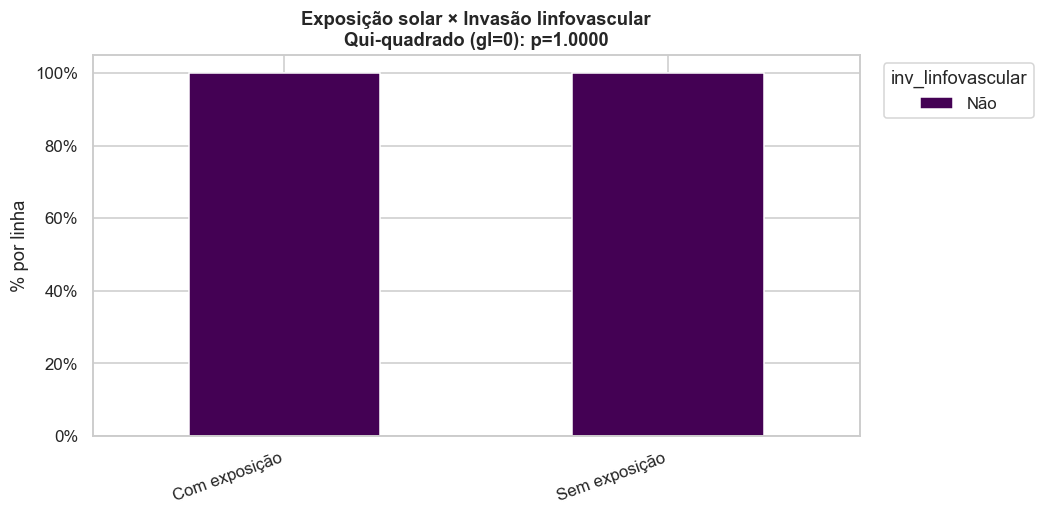

Significativo (α=0,05)? NÃO


In [40]:
analisa("C","C4","exposicao_solar","inv_linfovascular",
        "Exposição solar × Invasão linfovascular", "C4_exp_x_linfovascular.png",
        ordem_lin=ORD_EXP)


=== [C5] Exposição solar × Margens comprometidas ===  (n = 319)
Frequências:
margem_comprometida  Livre  Comprometida
exposicao_solar                         
Com exposição          192            34
Sem exposição           86             7

% por linha:
margem_comprometida  Livre  Comprometida
exposicao_solar                         
Com exposição         85.0          15.0
Sem exposição         92.5           7.5

Qui²=2.687, gl=1, p=0.1012 | Fisher p=0.0961 | V Cramer=0.102


[figura] C5_exp_x_margens.png


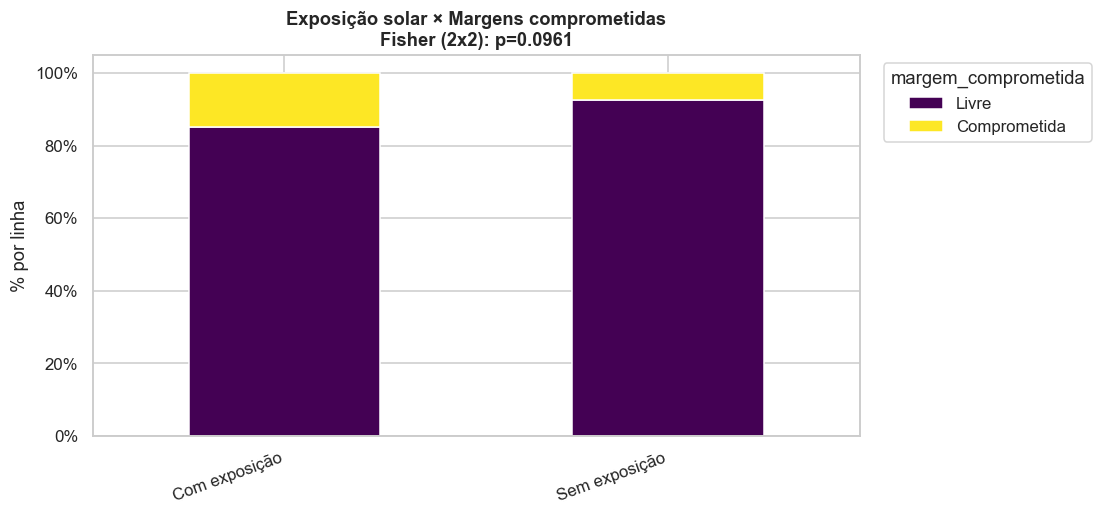

Significativo (α=0,05)? NÃO


In [41]:
analisa("C","C5","exposicao_solar","margem_comprometida",
        "Exposição solar × Margens comprometidas", "C5_exp_x_margens.png",
        ordem_lin=ORD_EXP, ordem_col=["Livre","Comprometida"])


=== [C6] Exposição solar × Tamanho da lesão (cm) ===  (n = 322)
                   n  média  desvio  mediana   q1   q3
exposicao_solar                                       
Com exposição    228   1.55    1.18      1.2  0.9  2.0
Sem exposição     94   1.15    0.68      1.0  0.7  1.4

Mann-Whitney: U=8499.5, p=0.0034 | r=0.207


[figura] C6_exp_x_tamanho.png


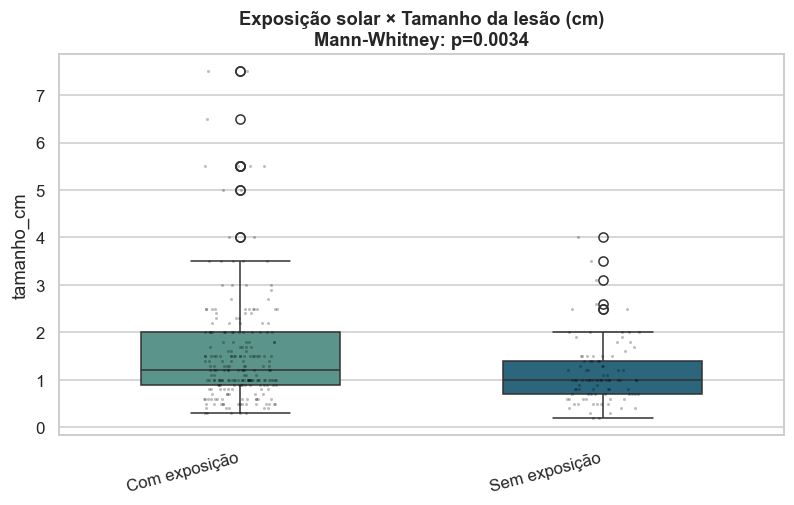

Significativo (α=0,05)? SIM


In [42]:
analisa("C","C6","exposicao_solar","tamanho_cm",
        "Exposição solar × Tamanho da lesão (cm)", "C6_exp_x_tamanho.png",
        ordem_lin=ORD_EXP, continua=True)


=== [C7] Exposição solar × Grau de infiltração ===  (n = 297)
Frequências:
grau_infiltracao  1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
exposicao_solar                                                           
Com exposição           28                 139                       43   
Sem exposição           14                  55                        7   

grau_infiltracao  4. Estruturas profundas  
exposicao_solar                            
Com exposição                           6  
Sem exposição                           5  

% por linha:
grau_infiltracao  1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
exposicao_solar                                                           
Com exposição         13.0                64.4                     19.9   
Sem exposição         17.3                67.9                      8.6   

grau_infiltracao  4. Estruturas profundas  
exposicao_solar                            
Com exposição                         2.8  


[figura] C7_exp_x_grau.png


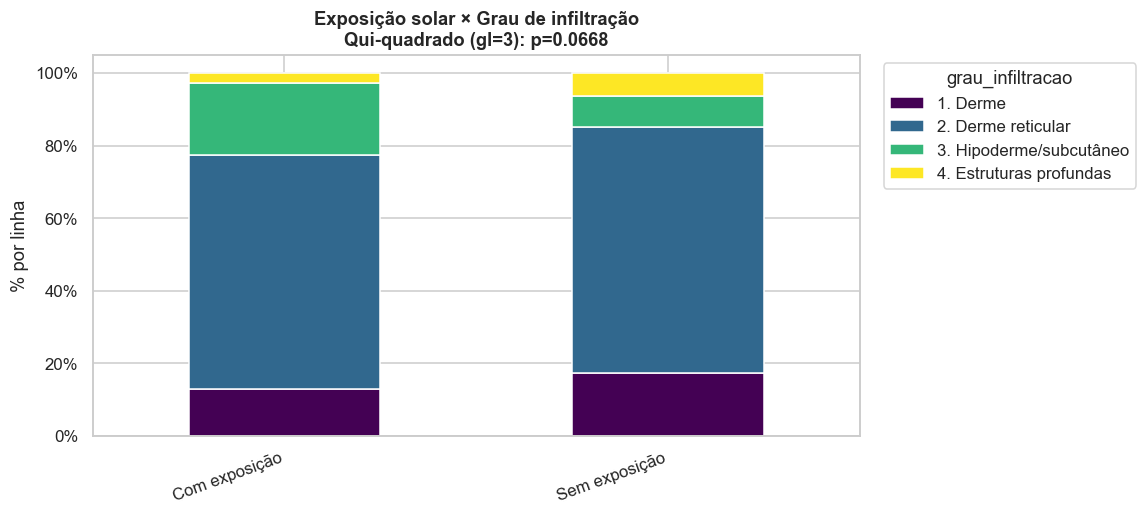

Significativo (α=0,05)? NÃO


In [43]:
analisa("C","C7","exposicao_solar","grau_infiltracao",
        "Exposição solar × Grau de infiltração", "C7_exp_x_grau.png",
        ordem_lin=ORD_EXP, ordem_col=ORDEM_GRAU)

## 11. Bloco D — Região anatômica × variáveis clínicas e patológicas

Avalia-se a relação entre a localização anatômica da lesão e as demais
variáveis. A face é mantida em sub-regiões pelo seu peso clínico (impacto
sobre conduta cirúrgica); as demais localizações são agrupadas por território.


=== [D1] Região × Exposição solar ===  (n = 322)
Frequências:
exposicao_solar             Com exposição  Sem exposição
regiao_grupo                                            
Cervical                                3              3
Couro cabeludo                          3              2
Face — frontal                          8              8
Face — malar                           30              7
Face — nariz                           77             27
Face — outros                           2              0
Face — perioral                        18              8
Face — pálpebra/periocular             12              6
Face — têmpora                          7             10
Membro inferior                         3              1
Membro superior                        19              9
Pavilhão/peri-auricular                30              8
Tronco/dorso                           16              5

% por linha:
exposicao_solar             Com exposição  Sem exposição
regiao_grup

[figura] D1_regiao_x_exposicao.png


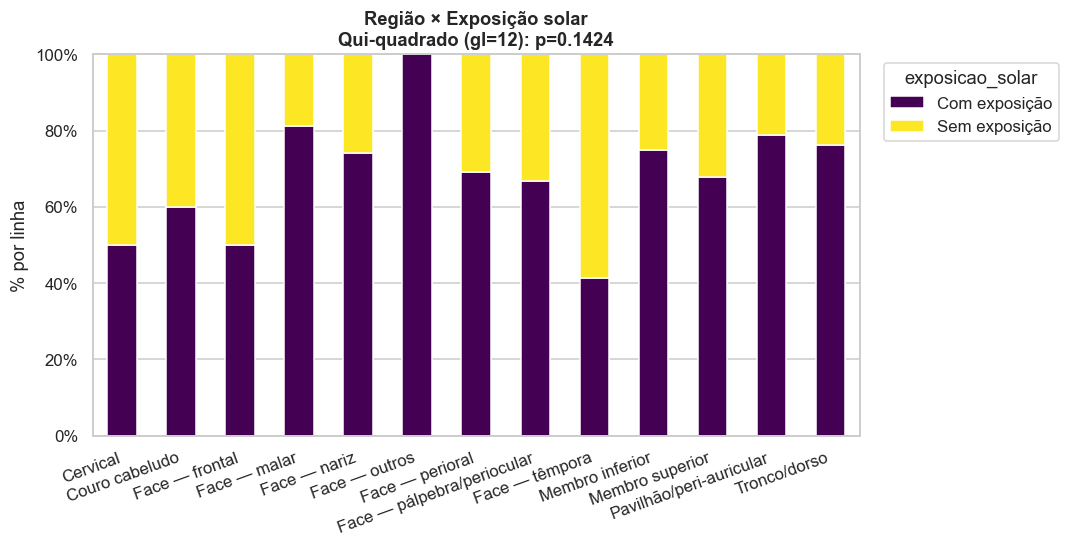

Significativo (α=0,05)? NÃO


In [44]:
analisa("D","D1","regiao_grupo","exposicao_solar",
        "Região × Exposição solar", "D1_regiao_x_exposicao.png",
        ordem_col=["Com exposição","Sem exposição"])


=== [D2] Região × Subtipo (3 cat) ===  (n = 419)
Frequências:
subtipo_3cat                Misto  Alto risco
regiao_grupo                                 
Cervical                        6           2
Couro cabeludo                  2           3
Face — frontal                 17           5
Face — malar                   31          16
Face — nariz                   79          43
Face — outros                   3           0
Face — perioral                22          10
Face — pálpebra/periocular     16          11
Face — têmpora                 15           5
Membro inferior                 0           5
Membro superior                25          13
Outros                          0           1
Pavilhão/peri-auricular        28          20
Tronco/dorso                   28          13

% por linha:
subtipo_3cat                Misto  Alto risco
regiao_grupo                                 
Cervical                     75.0        25.0
Couro cabeludo               40.0        60.0
Fac

[figura] D2_regiao_x_subtipo.png


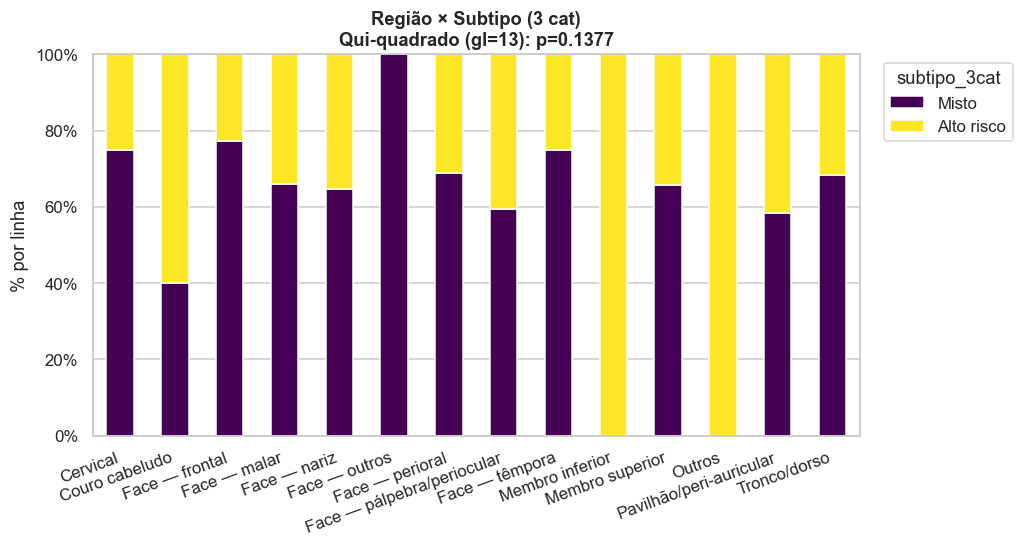

Significativo (α=0,05)? NÃO


In [45]:
analisa("D","D2","regiao_grupo","subtipo_3cat",
        "Região × Subtipo (3 cat)", "D2_regiao_x_subtipo.png",
        ordem_col=ORDEM_SUB)


=== [D3] Região × Margens comprometidas ===  (n = 416)
Frequências:
margem_comprometida         Livre  Comprometida
regiao_grupo                                   
Cervical                        8             0
Couro cabeludo                  3             2
Face — frontal                 19             3
Face — malar                   43             3
Face — nariz                  101            20
Face — outros                   3             0
Face — perioral                29             3
Face — pálpebra/periocular     18             8
Face — têmpora                 16             4
Membro inferior                 3             2
Membro superior                36             2
Outros                          1             0
Pavilhão/peri-auricular        43             5
Tronco/dorso                   40             1

% por linha:
margem_comprometida         Livre  Comprometida
regiao_grupo                                   
Cervical                    100.0           0.0
Couro

[figura] D3_regiao_x_margens.png


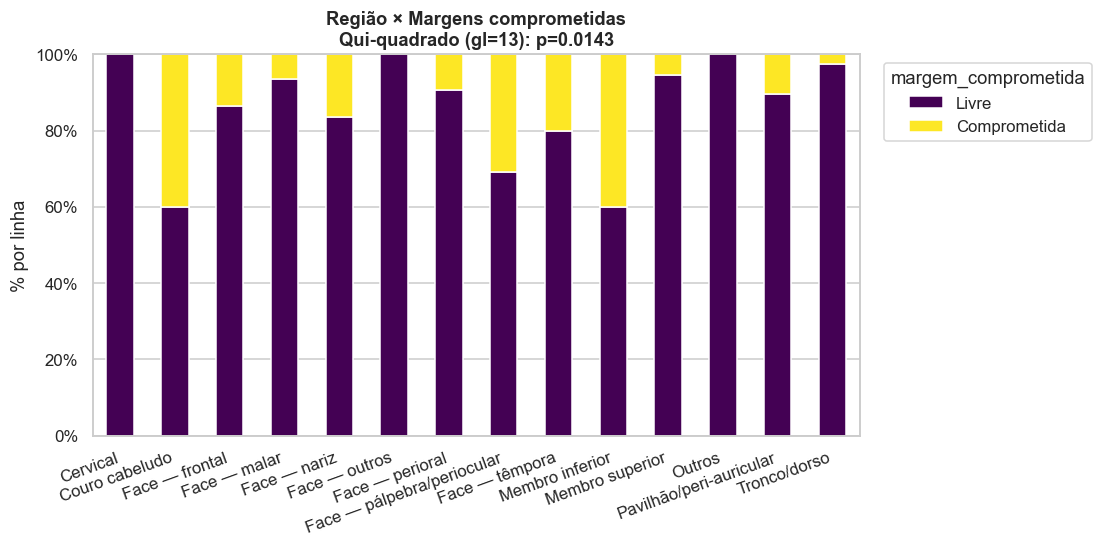

Significativo (α=0,05)? SIM


In [46]:
analisa("D","D3","regiao_grupo","margem_comprometida",
        "Região × Margens comprometidas", "D3_regiao_x_margens.png",
        ordem_col=["Livre","Comprometida"])


=== [D4] Região × Invasão perineural ===  (n = 415)
Frequências:
inv_perineural              Não  Sim
regiao_grupo                        
Cervical                      7    1
Couro cabeludo                5    0
Face — frontal               21    1
Face — malar                 45    2
Face — nariz                119    3
Face — outros                 3    0
Face — perioral              31    0
Face — pálpebra/periocular   24    3
Face — têmpora               16    3
Membro inferior               5    0
Membro superior              34    3
Outros                        1    0
Pavilhão/peri-auricular      47    0
Tronco/dorso                 37    4

% por linha:
inv_perineural                Não   Sim
regiao_grupo                           
Cervical                     87.5  12.5
Couro cabeludo              100.0   0.0
Face — frontal               95.5   4.5
Face — malar                 95.7   4.3
Face — nariz                 97.5   2.5
Face — outros               100.0   0.0
Face — p

[figura] D4_regiao_x_perineural.png


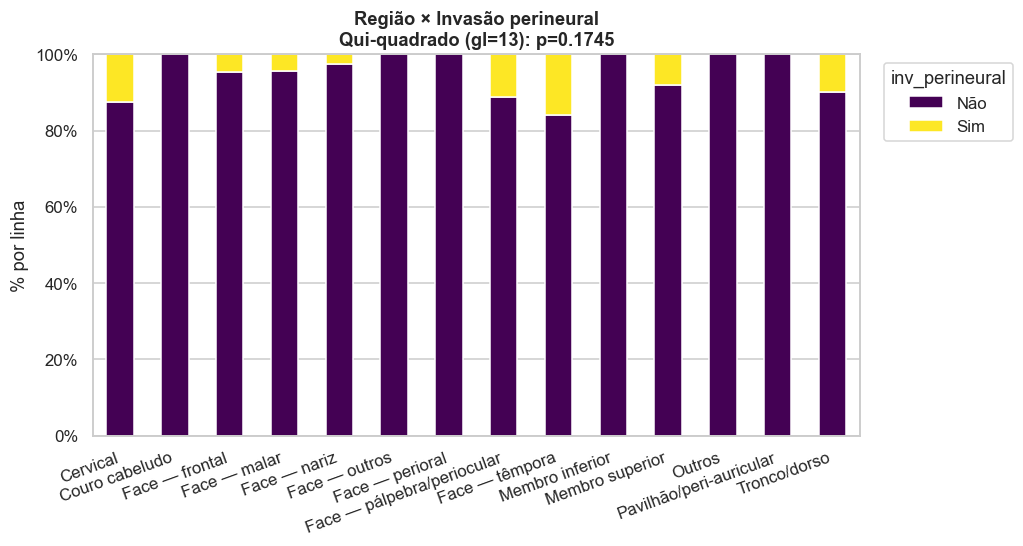

Significativo (α=0,05)? NÃO


In [47]:
analisa("D","D4","regiao_grupo","inv_perineural",
        "Região × Invasão perineural", "D4_regiao_x_perineural.png",
        ordem_col=["Não","Sim"])


=== [D5] Região × Invasão linfovascular ===  (n = 200)
Frequências:
inv_linfovascular           Não
regiao_grupo                   
Cervical                      2
Couro cabeludo                1
Face — frontal                6
Face — malar                 29
Face — nariz                 40
Face — outros                 2
Face — perioral              19
Face — pálpebra/periocular   15
Face — têmpora                9
Membro superior              27
Outros                        1
Pavilhão/peri-auricular      27
Tronco/dorso                 22

% por linha:
inv_linfovascular             Não
regiao_grupo                     
Cervical                    100.0
Couro cabeludo              100.0
Face — frontal              100.0
Face — malar                100.0
Face — nariz                100.0
Face — outros               100.0
Face — perioral             100.0
Face — pálpebra/periocular  100.0
Face — têmpora              100.0
Membro superior             100.0
Outros                      1

[figura] D5_regiao_x_linfovascular.png


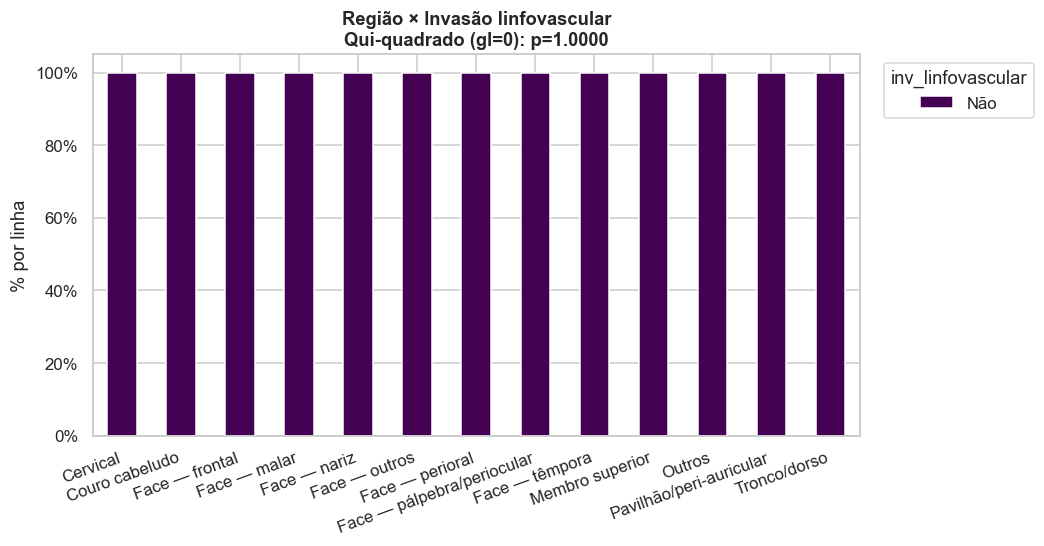

Significativo (α=0,05)? NÃO


In [48]:
analisa("D","D5","regiao_grupo","inv_linfovascular",
        "Região × Invasão linfovascular", "D5_regiao_x_linfovascular.png")


=== [D6] Região × Ulceração ===  (n = 415)
Frequências:
ulceracao                   Não  Sim
regiao_grupo                        
Cervical                      5    3
Couro cabeludo                2    3
Face — frontal               16    6
Face — malar                 16   31
Face — nariz                 36   85
Face — outros                 0    3
Face — perioral              11   20
Face — pálpebra/periocular   13   12
Face — têmpora                7   13
Membro inferior               2    3
Membro superior               7   31
Outros                        0    1
Pavilhão/peri-auricular      13   35
Tronco/dorso                 19   22

% por linha:
ulceracao                    Não    Sim
regiao_grupo                           
Cervical                    62.5   37.5
Couro cabeludo              40.0   60.0
Face — frontal              72.7   27.3
Face — malar                34.0   66.0
Face — nariz                29.8   70.2
Face — outros                0.0  100.0
Face — perioral  

[figura] D6_regiao_x_ulceracao.png


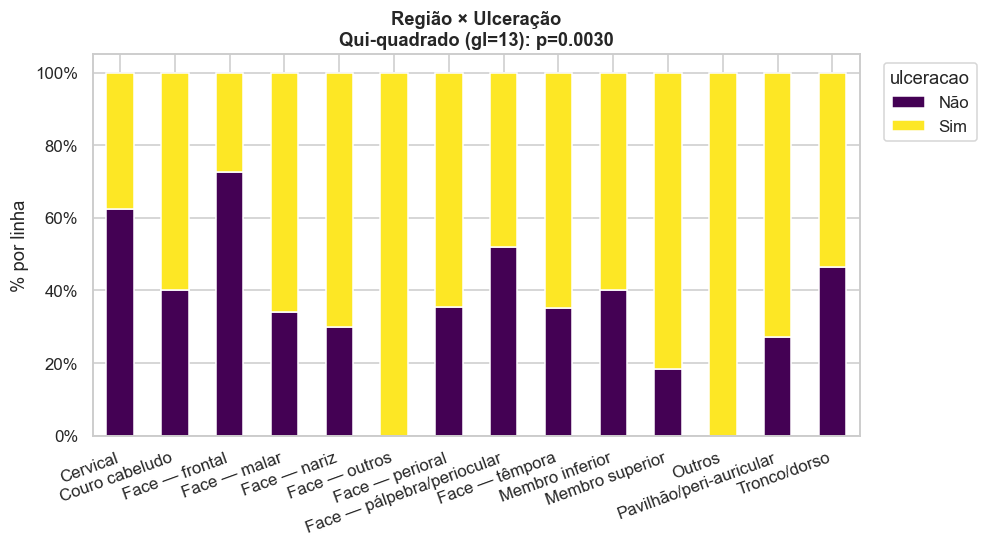

Significativo (α=0,05)? SIM


In [49]:
analisa("D","D6","regiao_grupo","ulceracao",
        "Região × Ulceração", "D6_regiao_x_ulceracao.png",
        ordem_col=["Não","Sim"])


=== [D7] Região × Grau de infiltração ===  (n = 389)


Frequências:
grau_infiltracao            1. Derme  2. Derme reticular  \
regiao_grupo                                               
Cervical                           1                   3   
Couro cabeludo                     3                   2   
Face — frontal                     4                  14   
Face — malar                       7                  31   
Face — nariz                      19                  79   
Face — outros                      1                   0   
Face — perioral                    2                  18   
Face — pálpebra/periocular         1                  15   
Face — têmpora                     3                  10   
Membro inferior                    2                   2   
Membro superior                    1                  26   
Outros                             0                   0   
Pavilhão/peri-auricular            4                  32   
Tronco/dorso                       6                  29   

grau_infiltracao         

[figura] D7_regiao_x_grau.png


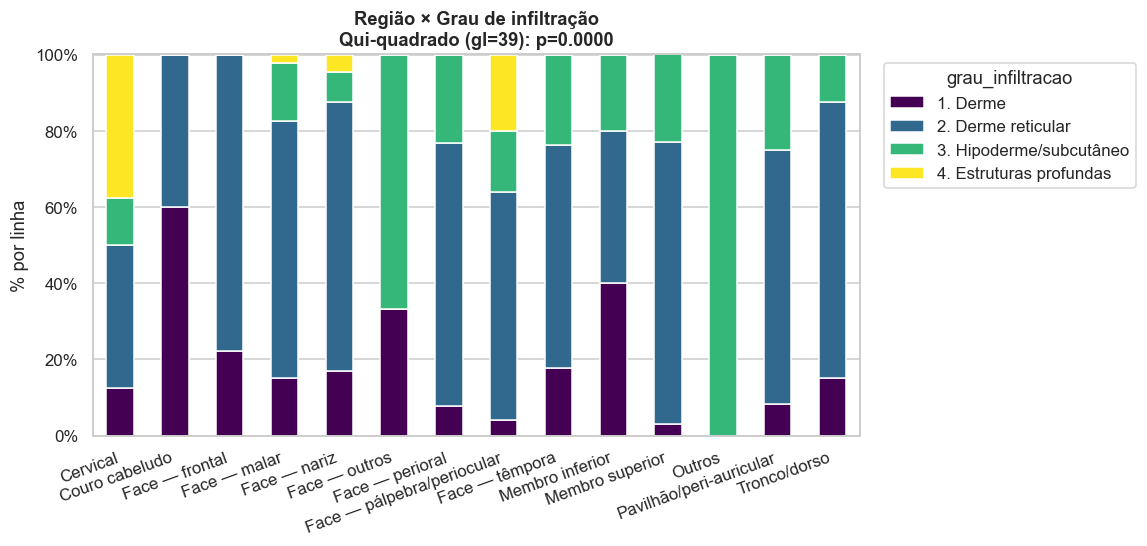

Significativo (α=0,05)? SIM


In [50]:
analisa("D","D7","regiao_grupo","grau_infiltracao",
        "Região × Grau de infiltração", "D7_regiao_x_grau.png",
        ordem_col=ORDEM_GRAU)


=== [D8] Região × Tamanho da lesão ===  (n = 418)
                              n  média  desvio  mediana    q1    q3
regiao_grupo                                                       
Cervical                      8   1.81    0.80     1.50  1.38  2.25
Couro cabeludo                5   1.66    0.55     1.50  1.50  1.80
Face — frontal               22   1.22    0.51     1.10  0.80  1.60
Face — malar                 47   1.74    1.32     1.40  0.95  2.00
Face — nariz                122   1.17    0.86     1.00  0.60  1.50
Face — outros                 3   2.27    2.37     0.90  0.90  2.95
Face — perioral              31   1.12    0.55     1.00  0.60  1.50
Face — pálpebra/periocular   27   1.23    0.87     1.00  0.60  1.50
Face — têmpora               20   1.32    1.22     1.00  0.70  1.12
Membro inferior               5   1.62    1.06     1.30  1.00  1.30
Membro superior              38   2.62    1.59     2.25  1.50  3.00
Outros                        1   0.80     NaN     0.80  0.80  0.

[figura] D8_regiao_x_tamanho.png


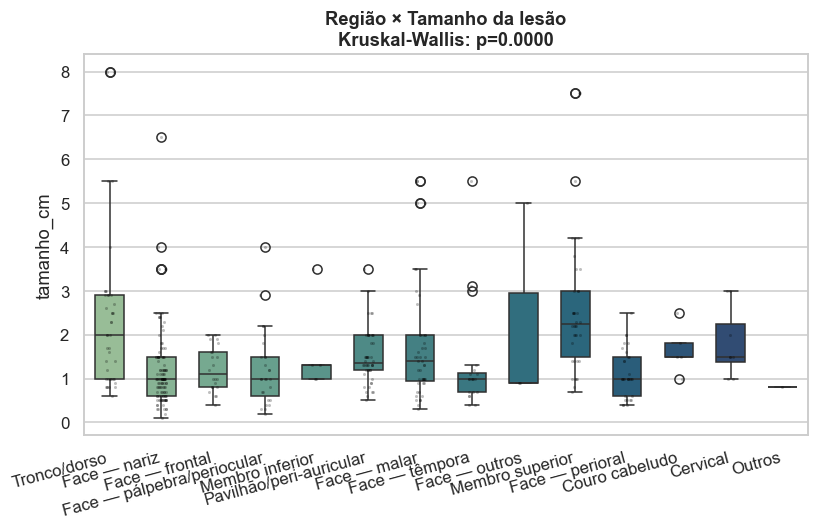

Significativo (α=0,05)? SIM


In [51]:
analisa("D","D8","regiao_grupo","tamanho_cm",
        "Região × Tamanho da lesão", "D8_regiao_x_tamanho.png", continua=True)

## 12. Bloco E — Subtipo do tumor (3 categorias) × variáveis clínicas e patológicas

Avalia-se a relação entre o subtipo histológico, classificado em três grupos
de risco (Baixo risco, Misto e Alto risco), e as demais variáveis clínicas e
patológicas. Este bloco incorpora os cruzamentos de subtipo originalmente
planejados (grau de infiltração, ulceração, invasão linfovascular, invasão
perineural).


=== [E1] Subtipo × Região anatômica ===  (n = 419)
Frequências:
regiao_grupo  Cervical  Couro cabeludo  Face — frontal  Face — malar  \
subtipo_3cat                                                           
Misto                6               2              17            31   
Alto risco           2               3               5            16   

regiao_grupo  Face — nariz  Face — outros  Face — perioral  \
subtipo_3cat                                                 
Misto                   79              3               22   
Alto risco              43              0               10   

regiao_grupo  Face — pálpebra/periocular  Face — têmpora  Membro inferior  \
subtipo_3cat                                                                
Misto                                 16              15                0   
Alto risco                            11               5                5   

regiao_grupo  Membro superior  Outros  Pavilhão/peri-auricular  Tronco/dorso  
subtipo_3

[figura] E1_subtipo_x_regiao.png


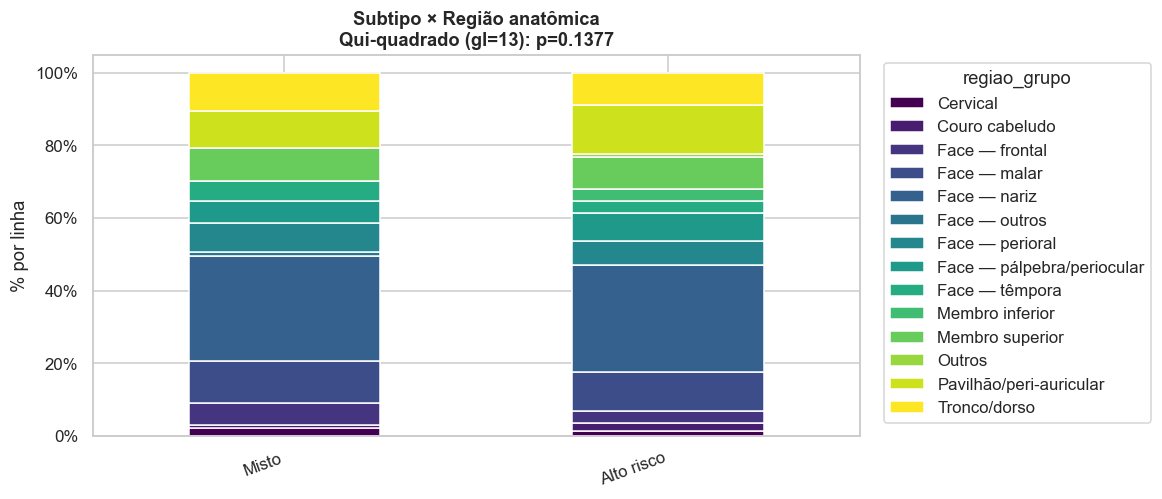

Significativo (α=0,05)? NÃO


In [52]:
analisa("E","E1","subtipo_3cat","regiao_grupo",
        "Subtipo × Região anatômica", "E1_subtipo_x_regiao.png",
        ordem_lin=ORDEM_SUB)


=== [E2] Subtipo × Invasão perineural ===  (n = 415)
Frequências:
inv_perineural  Não  Sim
subtipo_3cat            
Misto           254   16
Alto risco      141    4

% por linha:
inv_perineural   Não  Sim
subtipo_3cat             
Misto           94.1  5.9
Alto risco      97.2  2.8

Qui²=1.430, gl=1, p=0.2317 | Fisher p=0.2283 | V Cramer=0.071


[figura] E2_subtipo_x_perineural.png


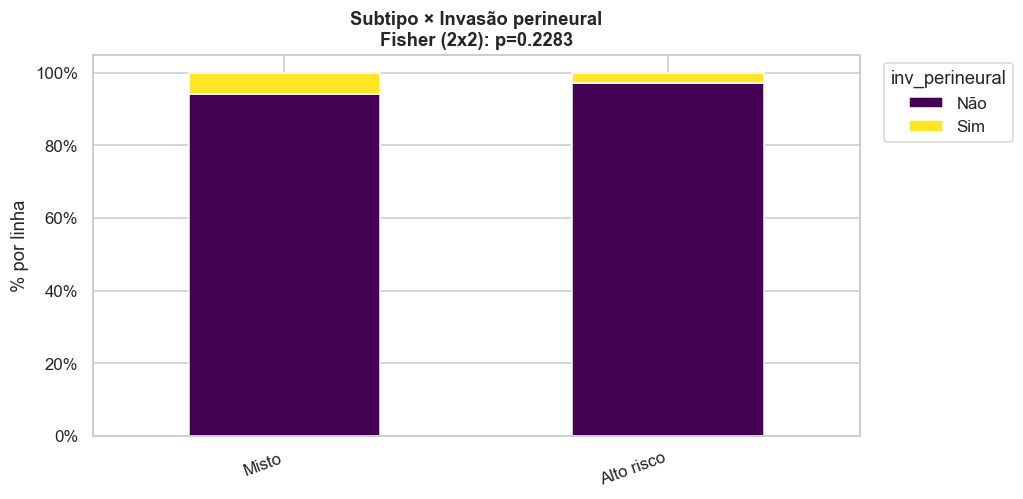

Significativo (α=0,05)? NÃO


In [53]:
analisa("E","E2","subtipo_3cat","inv_perineural",
        "Subtipo × Invasão perineural", "E2_subtipo_x_perineural.png",
        ordem_lin=ORDEM_SUB, ordem_col=["Não","Sim"])


=== [E3] Subtipo × Invasão linfovascular ===  (n = 200)
Frequências:
inv_linfovascular  Não
subtipo_3cat          
Misto              137
Alto risco          63

% por linha:
inv_linfovascular    Não
subtipo_3cat            
Misto              100.0
Alto risco         100.0

Qui²=0.000, gl=0, p=1.0000 | V Cramer=nan


[figura] E3_subtipo_x_linfovascular.png


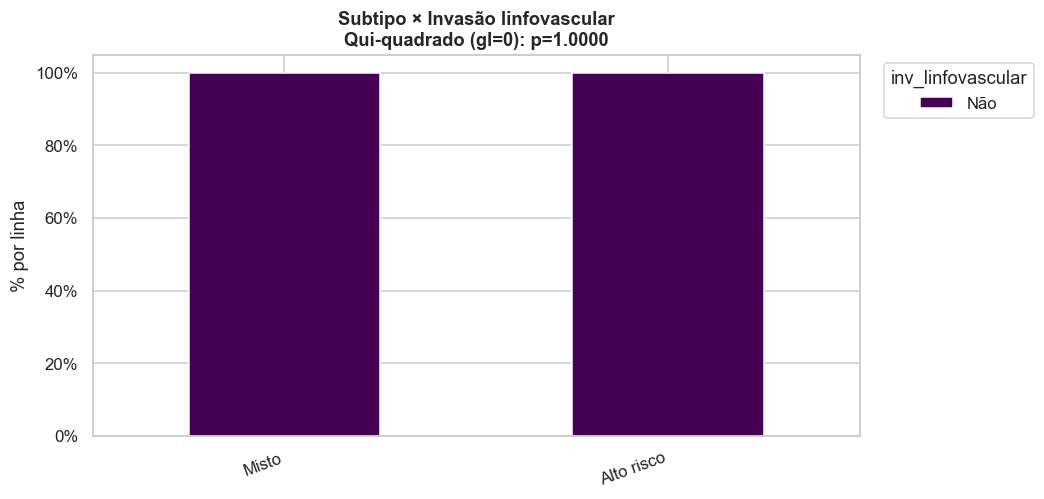

Significativo (α=0,05)? NÃO


In [54]:
analisa("E","E3","subtipo_3cat","inv_linfovascular",
        "Subtipo × Invasão linfovascular", "E3_subtipo_x_linfovascular.png",
        ordem_lin=ORDEM_SUB)


=== [E4] Subtipo × Grau de infiltração ===  (n = 389)
Frequências:
grau_infiltracao  1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
subtipo_3cat                                                              
Misto                   15                 183                       44   
Alto risco              39                  78                       16   

grau_infiltracao  4. Estruturas profundas  
subtipo_3cat                               
Misto                                  13  
Alto risco                              1  

% por linha:
grau_infiltracao  1. Derme  2. Derme reticular  3. Hipoderme/subcutâneo  \
subtipo_3cat                                                              
Misto                  5.9                71.8                     17.3   
Alto risco            29.1                58.2                     11.9   

grau_infiltracao  4. Estruturas profundas  
subtipo_3cat                               
Misto                                 5.1  
Alto ris

[figura] E4_subtipo_x_grau.png


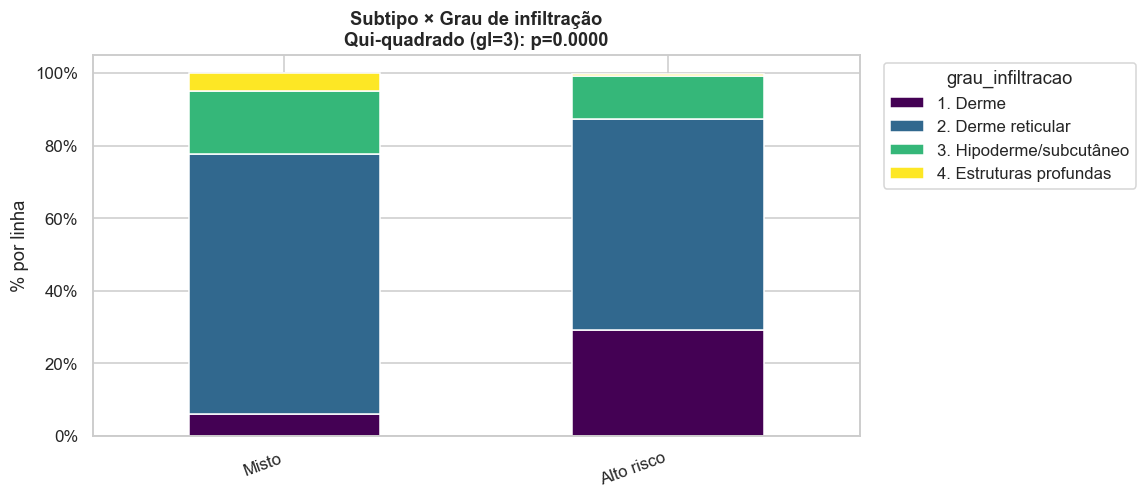

Significativo (α=0,05)? SIM


In [55]:
analisa("E","E4","subtipo_3cat","grau_infiltracao",
        "Subtipo × Grau de infiltração", "E4_subtipo_x_grau.png",
        ordem_lin=ORDEM_SUB, ordem_col=ORDEM_GRAU)


=== [E5] Subtipo × Margens comprometidas ===  (n = 416)
Frequências:
margem_comprometida  Livre  Comprometida
subtipo_3cat                            
Misto                  238            34
Alto risco             125            19

% por linha:
margem_comprometida  Livre  Comprometida
subtipo_3cat                            
Misto                 87.5          12.5
Alto risco            86.8          13.2



Qui²=0.002, gl=1, p=0.9621 | Fisher p=0.8776 | V Cramer=0.010


[figura] E5_subtipo_x_margens.png


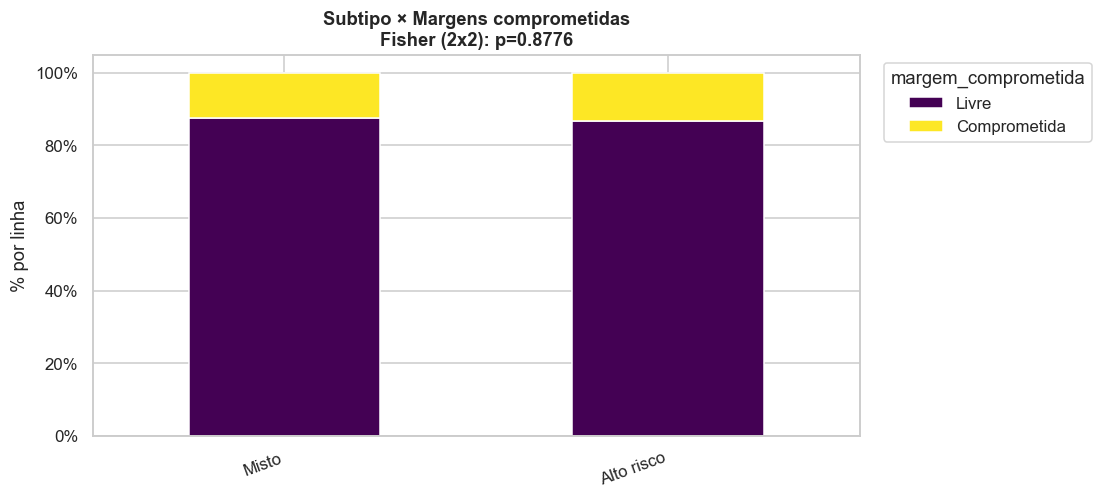

Significativo (α=0,05)? NÃO


In [56]:
analisa("E","E5","subtipo_3cat","margem_comprometida",
        "Subtipo × Margens comprometidas", "E5_subtipo_x_margens.png",
        ordem_lin=ORDEM_SUB, ordem_col=["Livre","Comprometida"])


=== [E6] Subtipo × Tamanho da lesão ===  (n = 418)
                n  média  desvio  mediana   q1   q3
subtipo_3cat                                       
Misto         272   1.62    1.19      1.3  0.9  2.0
Alto risco    146   1.43    1.18      1.0  0.7  1.5

Mann-Whitney: U=16835.5, p=0.0101 | r=0.152


[figura] E6_subtipo_x_tamanho.png


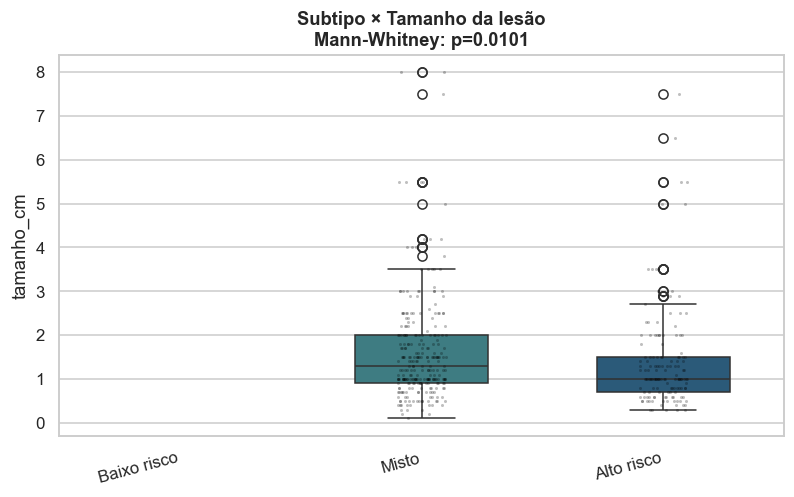

Significativo (α=0,05)? SIM


In [57]:
analisa("E","E6","subtipo_3cat","tamanho_cm",
        "Subtipo × Tamanho da lesão", "E6_subtipo_x_tamanho.png",
        ordem_lin=ORDEM_SUB, continua=True)


=== [E7] Subtipo × Ulceração ===  (n = 415)
Frequências:
ulceracao     Não  Sim
subtipo_3cat          
Misto          98  173
Alto risco     49   95

% por linha:
ulceracao      Não   Sim
subtipo_3cat            
Misto         36.2  63.8
Alto risco    34.0  66.0

Qui²=0.106, gl=1, p=0.7452 | Fisher p=0.7465 | V Cramer=0.021


[figura] E7_subtipo_x_ulceracao.png


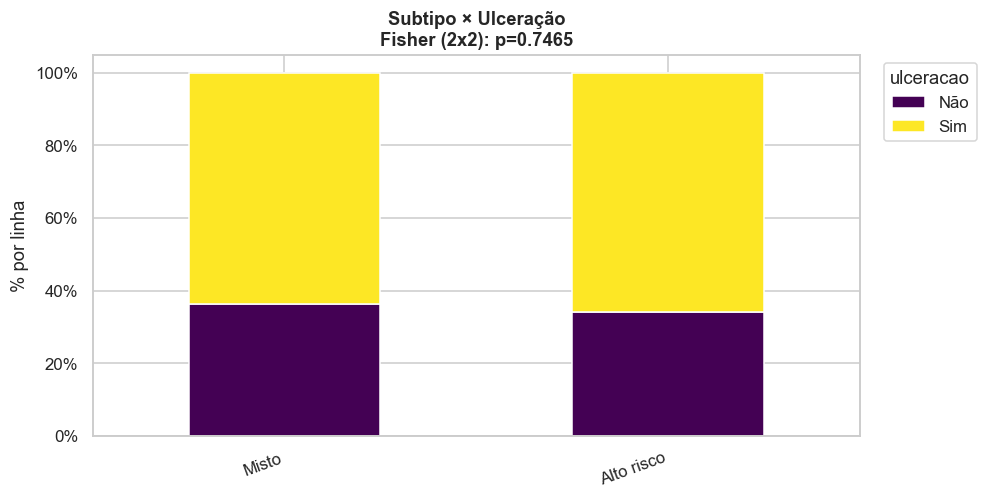

Significativo (α=0,05)? NÃO


In [58]:
analisa("E","E7","subtipo_3cat","ulceracao",
        "Subtipo × Ulceração", "E7_subtipo_x_ulceracao.png",
        ordem_lin=ORDEM_SUB, ordem_col=["Não","Sim"])

## 13. Bloco F — Tamanho da lesão: descritivo global e associações

Esta seção concentra a análise do tamanho da lesão (em cm): estatísticas
gerais e cruzamentos com ulceração, margens comprometidas, invasão perineural
e região anatômica (identificando o local mais acometido).

### 13.1. Descritivo geral do tamanho da lesão

n          418.00
média        1.56
desvio       1.19
mínimo       0.10
q1           0.82
mediana      1.20
q3           2.00
máximo       8.00
Name: tamanho_cm, dtype: float64


[figura] F0_tamanho_geral.png


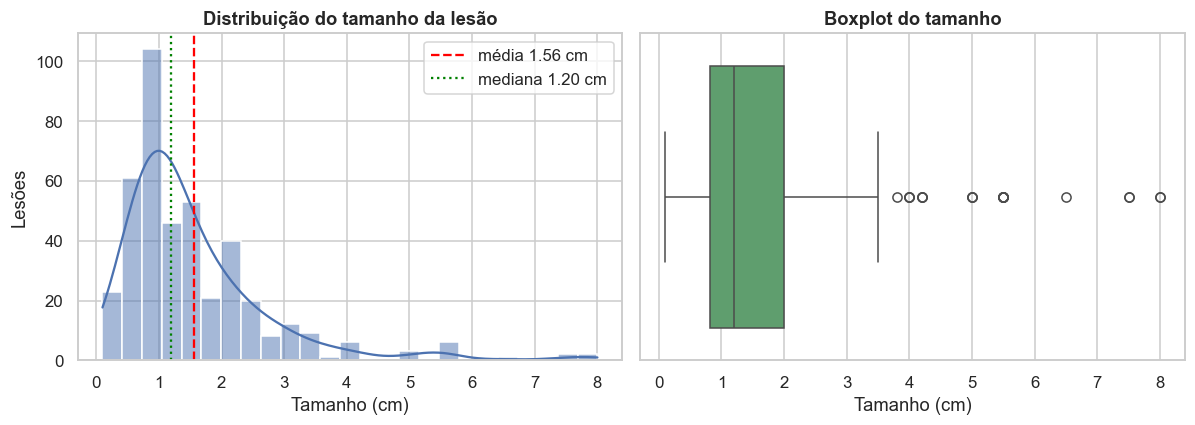

In [59]:
tam = df_lesao["tamanho_cm"].dropna()
desc = tam.describe()[["count","mean","std","min","25%","50%","75%","max"]]
desc.index = ["n","média","desvio","mínimo","q1","mediana","q3","máximo"]
print(desc.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(tam, bins=25, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(tam.mean(), color="red", ls="--", label=f"média {tam.mean():.2f} cm")
axes[0].axvline(tam.median(), color="green", ls=":", label=f"mediana {tam.median():.2f} cm")
axes[0].set(title="Distribuição do tamanho da lesão",
            xlabel="Tamanho (cm)", ylabel="Lesões")
axes[0].legend()
sns.boxplot(x=tam, ax=axes[1], color="#55A868")
axes[1].set(title="Boxplot do tamanho", xlabel="Tamanho (cm)")
plt.tight_layout(); salvar_fig("F0_tamanho_geral.png"); plt.show()

### 13.2. Tamanho × Ulceração


=== [F1] Tamanho da lesão × Ulceração ===  (n = 414)
             n  média  desvio  mediana   q1   q3
ulceracao                                       
Não        147   1.21    0.80      1.0  0.6  1.5
Sim        267   1.76    1.32      1.4  1.0  2.0

Mann-Whitney: U=13479.5, p=0.0000 | r=0.313


[figura] F1_tamanho_x_ulceracao.png


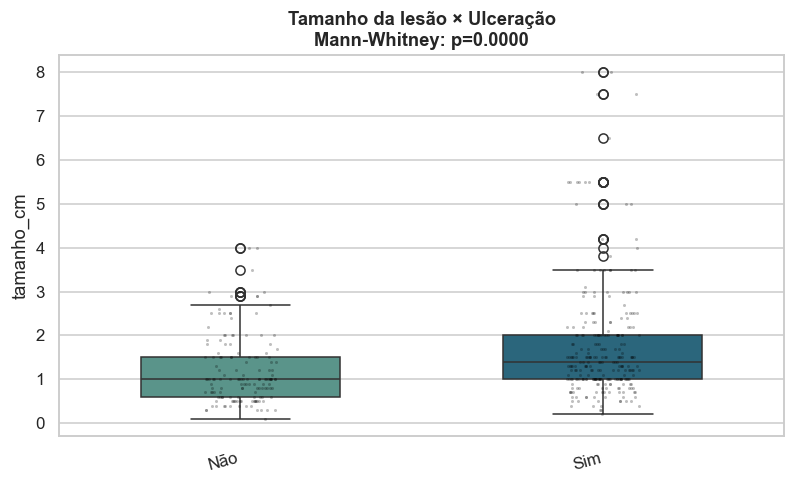

Significativo (α=0,05)? SIM


In [60]:
analisa("F","F1","ulceracao","tamanho_cm",
        "Tamanho da lesão × Ulceração", "F1_tamanho_x_ulceracao.png",
        ordem_lin=["Não","Sim"], continua=True)

### 13.3. Tamanho × Margens comprometidas


=== [F2] Tamanho da lesão × Margens comprometidas ===  (n = 415)
                       n  média  desvio  mediana   q1    q3
margem_comprometida                                        
Comprometida          52   1.72    1.12     1.45  1.0  2.05
Livre                363   1.54    1.20     1.20  0.8  2.00

Mann-Whitney: U=7979.0, p=0.0706 | r=0.155


[figura] F2_tamanho_x_margens.png


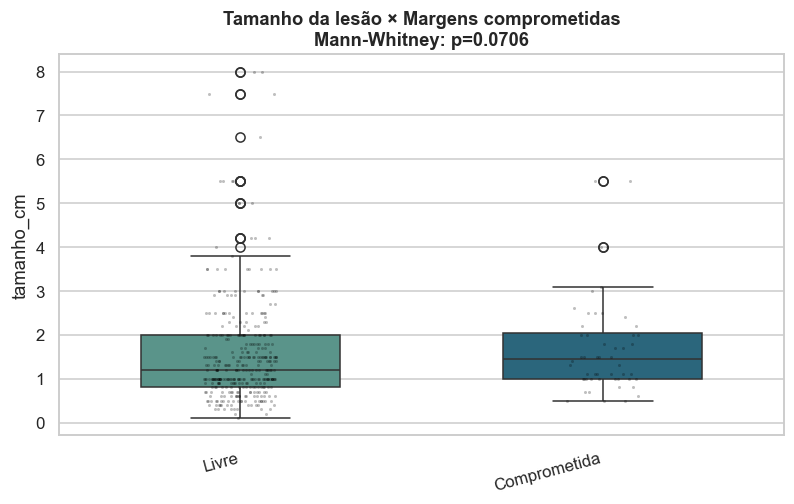

Significativo (α=0,05)? NÃO


In [61]:
analisa("F","F2","margem_comprometida","tamanho_cm",
        "Tamanho da lesão × Margens comprometidas",
        "F2_tamanho_x_margens.png",
        ordem_lin=["Livre","Comprometida"], continua=True)

### 13.4. Tamanho × Invasão perineural


=== [F3] Tamanho da lesão × Invasão perineural ===  (n = 414)
                  n  média  desvio  mediana    q1   q3
inv_perineural                                        
Não             394   1.52    1.12      1.2  0.80  1.9
Sim              20   2.44    2.03      2.0  1.27  2.6

Mann-Whitney: U=2411.5, p=0.0033 | r=0.388


[figura] F3_tamanho_x_perineural.png


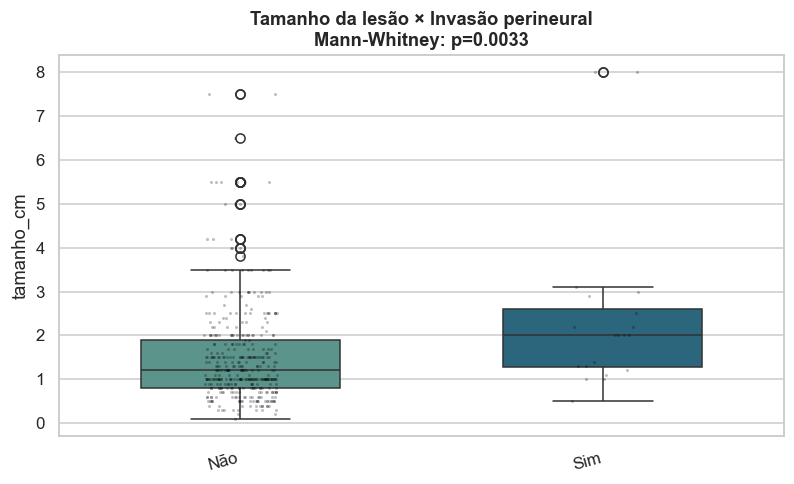

Significativo (α=0,05)? SIM


In [62]:
analisa("F","F3","inv_perineural","tamanho_cm",
        "Tamanho da lesão × Invasão perineural",
        "F3_tamanho_x_perineural.png",
        ordem_lin=["Não","Sim"], continua=True)

### 13.5. Tamanho médio por região anatômica
Tabela ordenada da maior para a menor média de tamanho, identificando os
locais mais acometidos por lesões maiores.

                              n  média  desvio  mediana    q1    q3
regiao_grupo                                                       
Membro superior              38   2.62    1.59     2.25  1.50  3.00
Tronco/dorso                 41   2.33    1.75     2.00  1.00  2.90
Face — outros                 3   2.27    2.37     0.90  0.90  2.95
Cervical                      8   1.81    0.80     1.50  1.38  2.25
Face — malar                 47   1.74    1.32     1.40  0.95  2.00
Couro cabeludo                5   1.66    0.55     1.50  1.50  1.80
Membro inferior               5   1.62    1.06     1.30  1.00  1.30
Pavilhão/peri-auricular      48   1.50    0.62     1.35  1.20  2.00
Face — têmpora               20   1.32    1.22     1.00  0.70  1.12
Face — pálpebra/periocular   27   1.23    0.87     1.00  0.60  1.50
Face — frontal               22   1.22    0.51     1.10  0.80  1.60
Face — nariz                122   1.17    0.86     1.00  0.60  1.50
Face — perioral              31   1.12    0.55  

[figura] F4_tamanho_medio_por_regiao.png


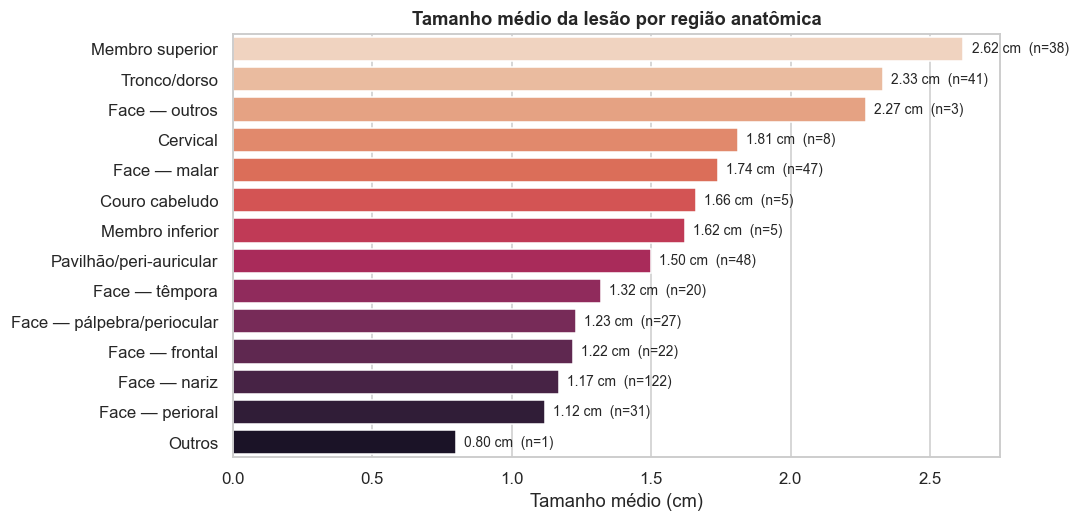

In [63]:
tam_regiao = (df_lesao.dropna(subset=["regiao_grupo","tamanho_cm"])
              .groupby("regiao_grupo", observed=True)["tamanho_cm"]
              .agg(["count","mean","std","median",
                    lambda x: x.quantile(.25), lambda x: x.quantile(.75)]))
tam_regiao.columns = ["n","média","desvio","mediana","q1","q3"]
tam_regiao = tam_regiao.sort_values("média", ascending=False).round(2)
print(tam_regiao)

fig, ax = plt.subplots(figsize=(9, 5))
o = tam_regiao.index.tolist()
sns.barplot(x=tam_regiao["média"], y=o, ax=ax, palette="rocket_r")
for i, (m, n) in enumerate(zip(tam_regiao["média"], tam_regiao["n"])):
    ax.text(m+0.03, i, f"{m:.2f} cm  (n={n})", va="center", fontsize=9)
ax.set(title="Tamanho médio da lesão por região anatômica",
       xlabel="Tamanho médio (cm)", ylabel="")
salvar_fig("F4_tamanho_medio_por_regiao.png"); plt.show()

### 13.6. Local mais acometido — distribuição geral das lesões
Frequência absoluta por região anatômica, independente do tamanho.

                              n     %
regiao_grupo                         
Face — nariz                122  29.1
Pavilhão/peri-auricular      48  11.5
Face — malar                 47  11.2
Tronco/dorso                 41   9.8
Membro superior              38   9.1
Face — perioral              32   7.6
Face — pálpebra/periocular   27   6.4
Face — frontal               22   5.3
Face — têmpora               20   4.8
Cervical                      8   1.9
Membro inferior               5   1.2
Couro cabeludo                5   1.2
Face — outros                 3   0.7
Outros                        1   0.2


[figura] F5_freq_regiao.png


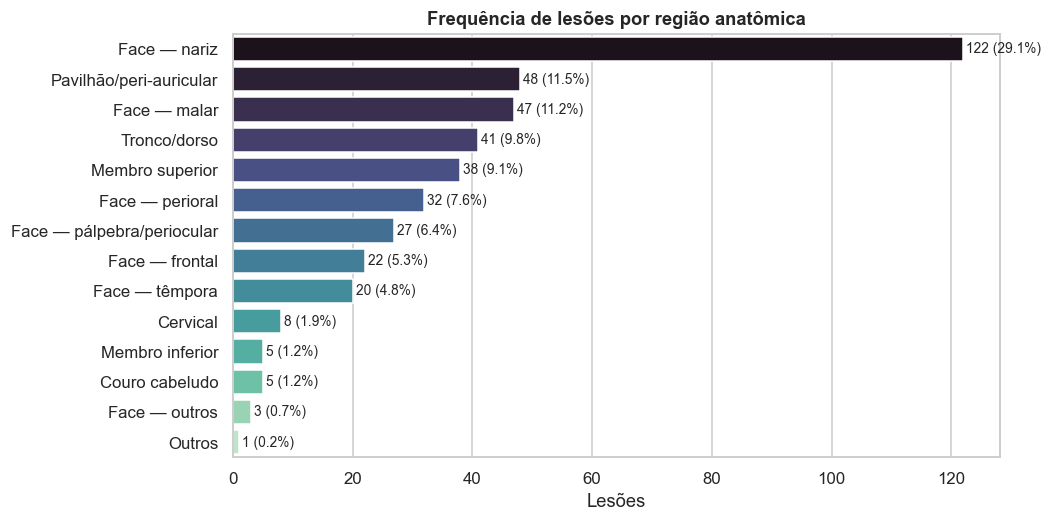

In [64]:
freq_regiao = df_lesao["regiao_grupo"].value_counts(dropna=False)
pct_regiao = (freq_regiao/freq_regiao.sum()*100).round(1)
tab_local = pd.DataFrame({"n": freq_regiao, "%": pct_regiao})
print(tab_local)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=freq_regiao.values, y=freq_regiao.index.astype(str),
            ax=ax, palette="mako")
for i, (v, p) in enumerate(zip(freq_regiao.values, pct_regiao.values)):
    ax.text(v+0.5, i, f"{v} ({p}%)", va="center", fontsize=9)
ax.set(title="Frequência de lesões por região anatômica",
       xlabel="Lesões", ylabel="")
salvar_fig("F5_freq_regiao.png"); plt.show()

## 14. Perfil clínico-patológico dos três subtipos histológicos

Esta seção apresenta os três grupos de subtipo (Baixo risco, Misto, Alto risco)
lado a lado, com média de tamanho da lesão, frequência de ulceração, margens
comprometidas, invasão perineural e linfovascular, e as três regiões anatômicas
mais frequentes. Permite comparação direta entre os subtipos.

In [65]:
def percentual(serie, valor):
    s = serie.dropna()
    return round((s == valor).mean()*100, 1) if len(s) else np.nan

perfil = []
for sub in ORDEM_SUB:
    g = df_lesao[df_lesao["subtipo_3cat"] == sub]
    if len(g) == 0: continue
    tam_g = g["tamanho_cm"].dropna()
    top_regioes = g["regiao_grupo"].value_counts().head(3)
    top_str = "; ".join(f"{k} ({v})" for k, v in top_regioes.items())
    grau_codes = g["grau_infiltracao"].cat.codes.replace(-1, np.nan)
    pct_profundo = round(((grau_codes >= 2).sum() /
                          grau_codes.notna().sum() * 100), 1) \
                   if grau_codes.notna().sum() else np.nan
    perfil.append({
        "Subtipo": sub,
        "n lesões": len(g),
        "Tamanho médio (cm)": round(tam_g.mean(), 2) if len(tam_g) else np.nan,
        "Tamanho mediana (cm)": round(tam_g.median(), 2) if len(tam_g) else np.nan,
        "% Ulceração": percentual(g["ulceracao"], "Sim"),
        "% Margens comprometidas": percentual(g["margem_comprometida"], "Comprometida"),
        "% Invasão perineural": percentual(g["inv_perineural"], "Sim"),
        "% Invasão linfovascular": percentual(g["inv_linfovascular"], "Sim"),
        "% Profundidade ≥ Hipoderme": pct_profundo,
        "Top 3 regiões": top_str,
    })
perfil_df = pd.DataFrame(perfil).set_index("Subtipo")
perfil_df.to_excel("perfil_subtipos.xlsx")
print("Perfil exportado: perfil_subtipos.xlsx\n")
perfil_df

Perfil exportado: perfil_subtipos.xlsx



,n lesões,Tamanho médio (cm),Tamanho mediana (cm),% Ulceração,% Margens comprometidas,% Invasão perineural,% Invasão linfovascular,% Profundidade ≥ Hipoderme,Top 3 regiões
Subtipo,,,,,,,,,
Misto,272,1.62,1.3,63.8,12.5,5.9,0.0,22.4,Face — nariz (79); Face — malar (31); Pavilhão...
Alto risco,147,1.43,1.0,66.0,13.2,2.8,0.0,12.7,Face — nariz (43); Pavilhão/peri-auricular (20...


[figura] F6_perfil_3subtipos.png


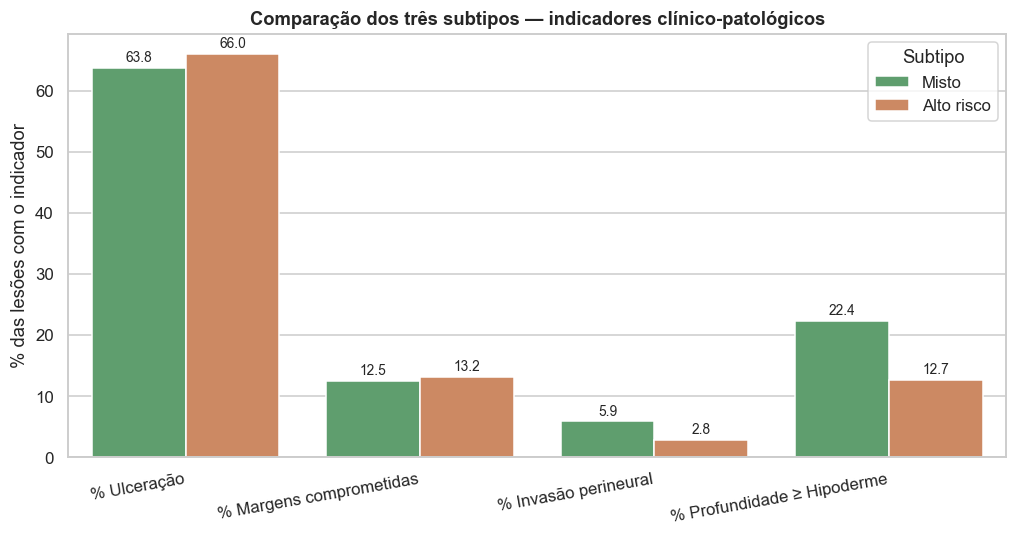

In [66]:
# gráfico comparativo dos 3 subtipos (percentuais lado a lado)
metricas = ["% Ulceração", "% Margens comprometidas",
            "% Invasão perineural", "% Profundidade ≥ Hipoderme"]
plot_df = perfil_df[metricas].reset_index().melt(id_vars="Subtipo",
                                                 var_name="Indicador",
                                                 value_name="Percentual")

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_df, x="Indicador", y="Percentual",
            hue="Subtipo", ax=ax, palette=["#55A868","#DD8452","#C44E52"])
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f", fontsize=9, padding=2)
ax.set(title="Comparação dos três subtipos — indicadores clínico-patológicos",
       ylabel="% das lesões com o indicador", xlabel="")
ax.legend(title="Subtipo", loc="upper right")
plt.xticks(rotation=10, ha="right")
salvar_fig("F6_perfil_3subtipos.png"); plt.show()

                n  média  desvio  mediana
subtipo_3cat                             
Misto         272   1.62    1.19      1.3
Alto risco    146   1.43    1.18      1.0


[figura] F7_tamanho_por_subtipo.png


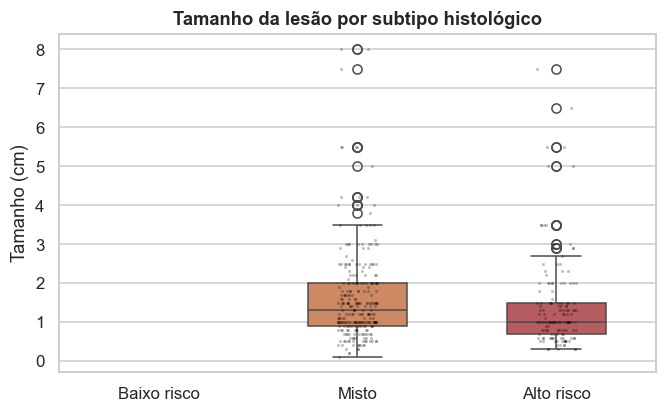

In [67]:
# gráfico do tamanho médio por subtipo
tam_sub = (df_lesao.dropna(subset=["subtipo_3cat","tamanho_cm"])
                   .groupby("subtipo_3cat", observed=True)["tamanho_cm"]
                   .agg(["count","mean","std","median"]))
tam_sub.columns = ["n","média","desvio","mediana"]
tam_sub = tam_sub.round(2)
print(tam_sub)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_lesao.dropna(subset=["subtipo_3cat","tamanho_cm"]),
            x="subtipo_3cat", y="tamanho_cm", order=ORDEM_SUB,
            ax=ax, palette=["#55A868","#DD8452","#C44E52"], width=.5)
sns.stripplot(data=df_lesao.dropna(subset=["subtipo_3cat","tamanho_cm"]),
              x="subtipo_3cat", y="tamanho_cm", order=ORDEM_SUB,
              ax=ax, color="black", alpha=.25, size=2)
ax.set(title="Tamanho da lesão por subtipo histológico",
       xlabel="", ylabel="Tamanho (cm)")
salvar_fig("F7_tamanho_por_subtipo.png"); plt.show()

## 15. Tabela-mestre de p-valores

Resumo consolidado de todos os testes realizados, com indicação dos resultados
significativos.

In [68]:
master = pd.DataFrame(RESULTADOS)
master["bloco"] = pd.Categorical(master["bloco"],
    categories=["Descritivo","Margens","A","B","C","D","E","F"], ordered=True)
master = master.sort_values(["bloco","codigo"]).reset_index(drop=True)
master.to_excel("resumo_pvalores.xlsx", index=False)
print(f"Total de testes: {len(master)}")
print(f"Significativos (p < 0,05): {(master['significativo']=='SIM').sum()}")
print(f"\nResumo exportado: resumo_pvalores.xlsx")

Total de testes: 42
Significativos (p < 0,05): 12

Resumo exportado: resumo_pvalores.xlsx


In [69]:
sig = master[master["significativo"]=="SIM"]
print("=== Cruzamentos significativos ===\n")
print(sig[["bloco","codigo","cruzamento","n","teste","p_valor","efeito"]].to_string(index=False))

=== Cruzamentos significativos ===

  bloco codigo                              cruzamento   n                teste  p_valor  efeito
Margens     M1                  Margens × Reincidência 409         Fisher (2x2)   0.0002   0.227
      B     B5         Faixa etária × Tamanho da lesão 416         Mann-Whitney   0.0000   0.539
      C     C2             Exposição solar × Ulceração 319         Fisher (2x2)   0.0143   0.140
      C     C6 Exposição solar × Tamanho da lesão (cm) 322         Mann-Whitney   0.0034   0.207
      D     D3          Região × Margens comprometidas 416 Qui-quadrado (gl=13)   0.0143   0.253
      D     D6                      Região × Ulceração 415 Qui-quadrado (gl=13)   0.0030   0.275
      D     D7            Região × Grau de infiltração 389 Qui-quadrado (gl=39)   0.0000   0.294
      D     D8               Região × Tamanho da lesão 418       Kruskal-Wallis   0.0000   0.186
      E     E4           Subtipo × Grau de infiltração 389  Qui-quadrado (gl=3)   0.0000   

In [70]:
master[["bloco","codigo","cruzamento","n","teste","p_valor","efeito","significativo"]]

,bloco,codigo,cruzamento,n,teste,p_valor,efeito,significativo
0,Descritivo,D1,Idade × Sexo (pacientes),283,Mann-Whitney,0.0820,0.122,não
1,Margens,M1,Margens × Reincidência,409,Fisher (2x2),0.0002,0.227,SIM
2,A,A1,Homens — Estado civil × Grau de infiltração,236,Qui-quadrado (gl=3),0.0855,0.167,não
3,A,A2,Homens — Estado civil × Tamanho da lesão (cm),248,Mann-Whitney,0.1099,-0.121,não
4,A,A3,Homens — Estado civil × Ulceração,246,Fisher (2x2),0.7756,0.022,não
5,A,A4,Homens — Estado civil × Margens comprometidas,245,Fisher (2x2),0.2442,0.082,não
6,A,A5,Mulheres — Estado civil × Grau de infiltração,147,Qui-quadrado (gl=3),0.1947,0.179,não
7,A,A6,Mulheres — Estado civil × Tamanho da lesão (cm),163,Mann-Whitney,0.5240,0.058,não
8,A,A7,Mulheres — Estado civil × Ulceração,162,Fisher (2x2),0.0818,0.146,não
9,A,A8,Mulheres — Estado civil × Margens comprometidas,164,Fisher (2x2),1.0000,0.004,não


## 14. Conclusões e limitações

### Síntese dos achados

**Perfil dos pacientes (n = 285):** idade média 70,6 anos (mediana 72; faixa
26–100), predomínio masculino (59,6%), com forte representação de
trabalhadores agrícolas/rurais (50,6%) e etnia branca, perfil coerente com
CBC associado à exposição solar crônica.

**Idade × sexo:** distribuições não-normais (Shapiro p < 0,01). Mann-Whitney
p = 0,082 — sem diferença estatisticamente significativa entre homens
(69,6 anos) e mulheres (72,1 anos).

**Composição do subtipo:** ao aplicar a classificação clínica padrão de CBC
(WHO/NCCN), nenhuma lesão da amostra ficou classificada como "Baixo risco"
puro — todas as 419 lesões apresentam pelo menos um componente histológico
agressivo. Os dois grupos efetivos são Misto (272 lesões, ambos os componentes)
e Alto risco puro (147 lesões, apenas componentes agressivos).

### Cruzamentos com associação estatisticamente significativa

**Margens × Reincidência (M1):** Fisher p = 0,0002. Lesões com margens
comprometidas reincidem em 18,0%, contra 3,1% das lesões com margens livres.

**Bloco B — Faixa etária × tamanho da lesão (B5):** Mann-Whitney p < 0,001;
r = 0,54 (efeito grande). Pacientes ≤ 40 anos apresentam lesões maiores
(mediana 2,3 cm; média 2,75) do que pacientes > 40 anos (mediana 1,2 cm;
média 1,49). Resultado contrário à hipótese de tumor menor no jovem. Possíveis
interpretações: diagnóstico tardio na faixa etária mais jovem (CBC não é
suspeitado precocemente) ou comportamento clínico mais expansivo. Os demais
marcadores de agressividade no Bloco B (margens, perineural, ulceração, grau,
subtipo) não diferiram entre as faixas etárias.

**Bloco C — Exposição solar ocupacional:**
- Ulceração (C2): Fisher p = 0,014. Lesões em trabalhadores expostos ao sol
  ulceram em 69,5%, contra 54,8% nos não expostos.
- Tamanho (C6): Mann-Whitney p = 0,003; r = 0,21. Lesões em expostos são
  maiores (mediana 1,2 cm; média 1,55) do que em não expostos (mediana 1,0 cm;
  média 1,15).

**Bloco D — Região anatômica:** o sítio anatômico associa-se a múltiplas
variáveis:
- Margens comprometidas (D3, qui-quadrado p = 0,014; V = 0,25).
- Ulceração (D6, p = 0,003; V = 0,28).
- Grau de infiltração (D7, p < 0,001; V = 0,29).
- Tamanho da lesão (D8, Kruskal-Wallis p < 0,001; η² = 0,19). As maiores
  lesões localizam-se em membro superior (mediana 2,25 cm) e tronco/dorso
  (2,0 cm); as menores, em face — nariz, perioral e pálpebra (~1,0 cm).

**Bloco E — Subtipo:**
- Grau de infiltração (E4, qui-quadrado p < 0,001; V = 0,33 — efeito
  moderado). Lesões mistas alcançam profundidades maiores (71,8% derme
  reticular, 17,3% hipoderme e 5,1% estruturas profundas) do que o Alto risco
  puro (58,2% reticular; 0,7% estruturas profundas). O resultado é coerente
  com a presença de componentes nodulares/sólidos associados, que conferem
  maior massa tumoral.
- Tamanho (E6, Mann-Whitney p = 0,010; r = 0,15). Lesões mistas têm tamanho
  ligeiramente maior (média 1,62 vs 1,43 cm).

### Achados não significativos relevantes

- **Bloco A — Estado civil × saúde:** nenhum dos oito cruzamentos atingiu
  significância (todos p > 0,05; o valor mais próximo foi A1, p = 0,086). A
  hipótese de doença mais avançada em homens sem companheira não foi
  confirmada nesta amostra.
- **Idade × sexo** (idade média): p = 0,082 — sem diferença significativa.
- **Invasão linfovascular** (B3, C4, D5, E3): todos sem variabilidade
  (ausência de casos positivos).

### Limitações

1. **Invasão linfovascular sem casos positivos** na base (200 "Não" e 219
   ausentes). Os cruzamentos envolvendo essa variável são descritivos e
   produzem p = 1,0 por construção.
2. **Faixa etária ≤ 40 com apenas 23 lesões** — poder estatístico reduzido
   para o Bloco B; resultados não significativos nessa faixa não excluem
   diferenças clínicas reais.
3. **Múltiplas lesões por paciente** (até 14 por código) — as observações
   por lesão não são totalmente independentes; os intervalos de confiança e
   p-valores subestimam ligeiramente a variabilidade.
4. **Sem correção para múltiplas comparações** — foram realizados 38 testes;
   alguns p < 0,05 podem ser falso-positivos por acaso. Aplicando uma correção
   conservadora de Bonferroni (α ≈ 0,0013), permanecem significativos:
   M1, B5, C6, D6, D7, D8 e E4.
5. **Classificação de subtipo** baseada em critérios clínicos padrão; a
   ausência de "Baixo risco" puro na amostra é coerente com o perfil de
   um serviço de patologia, mas pode representar viés de encaminhamento.
